# Final Evaluation: Does Deep Learning Add Value to American Put Pricing?

This notebook closes the project by bringing together the evidence produced in Notebooks 01–08 and answering one central question:

> **Does deep learning add enough accuracy, financial consistency, and computational efficiency to justify its use as a surrogate for American put pricing, rather than merely reproducing a numerical method with a neural network?**

The project began with the literature on neural option pricing. Instead of reproducing one published architecture exactly, it reproduced and extended the underlying research problem: whether a neural network can approximate an option-pricing function and whether that approximation has practical value.

The scope was deliberately narrowed to **American put options**. Unlike a European Black–Scholes price, the American value includes an early-exercise decision and generally requires a numerical method. This creates a more credible use case for a trained surrogate.

Because a complete, clean, and legally usable market dataset covering the required parameter domain was not available, Notebooks 02 and 03 generated a controlled synthetic dataset from a validated high-resolution Cox–Ross–Rubinstein model. The later notebooks then tested a sequence of increasingly structured approaches:

1. a direct MLP pricing baseline;
2. residual and financially constrained pricing models;
3. exercise-only and multi-task decision models;
4. classical and neural Longstaff–Schwartz methods;
5. an integrated multi-head model returning price, continuation value, and exercise information.

Notebook 09 does not train another model. It verifies that the evidence is comparable, consolidates the results, answers the seven research questions and six hypotheses, and evaluates the computational business case.

### Main conclusion in advance

The evidence supports a **conditional** use of deep learning. A financially constrained residual MLP is an accurate and economically coherent in-domain surrogate, and it accelerates large repeated pricing workloads. The numerical model remains necessary for label generation, validation, changed contract assumptions, and out-of-domain cases. More complex neural designs do not automatically improve the result: the integrated model is useful as a combined deployment compromise, while neural Longstaff–Schwartz does not outperform its classical counterpart in this experiment.

## 1. Reproducibility setup

The notebook can be executed from either the repository root or the `notebooks` directory. All final-evaluation outputs are written under `artifacts/final_evaluation/`.

The first sections are evidence-integrity controls. They confirm that the saved results from Notebooks 04–08 exist, correspond to the declared full or final execution profiles, and can be compared on compatible observations. These checks establish reproducibility and comparability; they do not determine which model is best.

In [1]:
from pathlib import Path
import sys
import json
import math
from collections.abc import Mapping
from shutil import copy2
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else NOTEBOOK_DIR
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.artifact_registry import (
    assert_required_artifacts_valid,
    audit_artifacts,
)
from src.evaluation.final_artifact_adapters import (
    build_package_summary,
    load_all_final_packages,
)
from src.evaluation.final_lineage_audit import (
    assert_phase_1_3_ready,
    audit_package_coherence,
    audit_static_prediction_alignment,
    build_lineage_inventory,
)

from src.evaluation.final_static_comparison import (
    assert_phase_4_ready,
    build_static_model_registry,
    run_phase_4_static_comparison,
)

from src.evaluation.final_phase_5_6 import (
    assert_phases_5_6_ready,
    run_phases_5_6,
)

from src.evaluation.final_charts import (
    generate_final_charts,
)

from src.evaluation.business_case_benchmark import (
    RuntimeScalingConfig,
)
from src.evaluation.final_business_case import (
    run_final_business_case,
)

from src.evaluation.final_phase_7_8 import (
    run_phase_7_8_pre_export,
)

from src.evaluation.final_reporting import (
    export_final_project,
    verify_export_manifest,
    write_export_manifest,
)
from src.evaluation.final_validation import (
    assert_phase_7_8_ready,
    build_post_export_readiness_audit,
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_evaluation"
    / "phase_1_3"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Audit output: {OUTPUT_DIR}")

Project root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing
Audit output: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\artifacts\final_evaluation\phase_1_3


## 2. Are all required experimental results available?

The artifact registry lists every dataset manifest, prediction table, checkpoint, model-selection file, runtime record, and training manifest required for the final comparison.

The audit verifies file presence and basic schema. Passing this check means that Notebook 09 is not silently substituting incomplete, smoke-mode, or stale outputs. Cross-file consistency is tested separately below.

In [2]:
artifact_audit = audit_artifacts(PROJECT_ROOT)

display(
    artifact_audit[
        [
            "notebook",
            "category",
            "name",
            "required_for_final",
            "found",
            "valid",
            "rows",
            "notes",
        ]
    ]
)

assert_required_artifacts_valid(artifact_audit)
print("Artifact contract: PASS")

,notebook,category,name,required_for_final,found,valid,rows,notes
0,None,data,production_dataset_manifest,True,True,True,NaN,JSON schema validated
1,04,final_metrics,nb04_final_metrics,True,True,True,NaN,JSON schema validated
2,04,test_predictions,nb04_test_predictions,True,True,True,187811.0,table schema validated
3,04,checkpoint,nb04_checkpoint,True,True,True,NaN,artifact exists and is non-empty
4,04,training_manifest,nb04_training_manifest,True,True,True,NaN,JSON schema validated
5,05,final_metrics,nb05_final_metrics,True,True,True,NaN,JSON schema validated
6,05,test_predictions,nb05_test_predictions,True,True,True,187811.0,table schema validated
7,05,checkpoint,nb05_checkpoint,True,True,True,NaN,artifact exists and is non-empty
8,05,training_manifest,nb05_training_manifest,True,True,True,NaN,JSON schema validated
9,06,final_metrics,nb06_final_metrics,True,True,True,NaN,JSON schema validated


Artifact contract: PASS


### Interpretation

All required artifacts from the production dataset and Notebooks 04–08 were found and passed the registry checks. This includes the aligned static prediction tables, Notebook 07 held-out contract results, and both the warm-start and scratch Notebook 08 packages.

This result confirms **availability and basic validity only**. It does not establish that the models are accurate or mutually consistent; those questions are addressed by the following audits.

## 3. Are the saved model packages internally coherent?

Each upstream notebook is loaded through an explicit package contract. The package audit verifies:

- notebook identity and completion status;
- the declared execution profile;
- selected model or configuration;
- canonical checkpoint name and file;
- prediction-table availability where applicable;
- agreement between training manifests and final packages.

This prevents the final evaluation from inferring model meaning from arbitrary filenames or accepting mismatched artifacts.

In [3]:
packages = load_all_final_packages(PROJECT_ROOT)
package_summary = build_package_summary(packages)
package_coherence = audit_package_coherence(packages)

display(package_summary)
display(package_coherence)

invalid_package_checks = package_coherence.loc[
    ~package_coherence["valid"]
]
if not invalid_package_checks.empty:
    display(invalid_package_checks)

print(
    "Package coherence: "
    f"{'PASS' if invalid_package_checks.empty else 'FAIL'}"
)

,notebook,notebook_id,status,training_profile,selected_model,checkpoint,checkpoint_path,benchmark_checkpoint_path,test_prediction_rows,benchmark_test_predictions_path,final_metrics_path
0,04,04_direct_mlp_pricer,complete,full,Direct MLP,best_direct_mlp.pt,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,None,187811.0,None,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
1,05,05_early_exercise_premium_model,complete,full,Constrained floor residual,best_premium_model.pt,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,None,187811.0,None,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
2,06,06_exercise_boundary_analysis,complete,full,Multi-task candidate: lambda_1,best_multitask_pricer.pt,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,None,187811.0,None,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
3,07,07_neural_longstaff_schwartz,complete,final,Classical LSM,neural_lsm_policy.pt,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,None,NaN,None,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
4,08,08_final_multihead_model,complete,full,Integrated deployment: warm_start,best_integrated_multihead.pt,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,187811.0,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...


,notebook,check,valid,details
0,04,final_package_complete,True,status='complete'
1,04,canonical_checkpoint_exists,True,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
2,04,checkpoint_name_matches_file,True,declared='best_direct_mlp.pt'; resolved='best_...
3,04,manifest_complete:training_complete.json,True,status='complete'
4,04,manifest_profile_matches:training_complete.json,True,manifest='full'; final='full'
5,04,test_predictions_exist,True,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
6,05,final_package_complete,True,status='complete'
7,05,canonical_checkpoint_exists,True,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
8,05,checkpoint_name_matches_file,True,declared='best_premium_model.pt'; resolved='be...
9,05,manifest_complete:training_complete.json,True,status='complete'


Package coherence: PASS


### Interpretation

The five upstream notebooks report completed full or final runs, and every package-level coherence check passes. The selected checkpoints, execution profiles, prediction tables, and training manifests agree with the final package declarations.

The table also clarifies an important distinction: Notebook 07 selects **classical LSM** as the preferred method even though a neural policy checkpoint exists. The checkpoint documents the neural experiment; it does not imply that the neural method won.

## 4. Are the static models evaluated on the same observations?

A ranking is meaningful only if the static models are evaluated on the same contracts and the same target values. Notebook 04 is used as the reference prediction set, and the prediction tables from Notebooks 05, 06, and 08 are aligned to it by immutable `sample_id`.

The audit also compares the exported option-state fields wherever those fields are available.

In [4]:
(
    static_prediction_alignment,
    static_field_alignment,
) = audit_static_prediction_alignment(packages)

display(static_prediction_alignment)
display(static_field_alignment)

lineage_inventory = build_lineage_inventory(
    PROJECT_ROOT,
    packages,
)
display(lineage_inventory)

,notebook,reference_notebook,observations,reference_observations,duplicate_sample_ids,missing_reference_ids,extra_candidate_ids,same_sample_id_set,target_max_absolute_difference,same_true_target,valid
0,04,04,187811,187811,0,0,0,True,0.000000e+00,True,True
1,05,04,187811,187811,0,0,0,True,0.000000e+00,True,True
2,06,04,187811,187811,0,0,0,True,0.000000e+00,True,True
3,08,04,187811,187811,0,0,0,True,2.980137e-08,True,True
4,08_scratch,04,187811,187811,0,0,0,True,2.980137e-08,True,True


,notebook,field,observations,max_absolute_difference,matches,note
0,04,moneyness,187811,0.0,True,rtol=1e-07; atol=1e-07
1,04,log_moneyness,187811,0.0,True,rtol=1e-07; atol=1e-07
2,04,time_to_maturity,187811,0.0,True,rtol=1e-07; atol=1e-07
3,04,risk_free_rate,187811,0.0,True,rtol=1e-07; atol=1e-07
4,04,dividend_yield,187811,0.0,True,rtol=1e-07; atol=1e-07
5,04,volatility,187811,0.0,True,rtol=1e-07; atol=1e-07
6,05,moneyness,187811,0.0,True,rtol=1e-07; atol=1e-07
7,05,log_moneyness,187811,0.0,True,rtol=1e-07; atol=1e-07
8,05,time_to_maturity,187811,0.0,True,rtol=1e-07; atol=1e-07
9,05,risk_free_rate,187811,0.0,True,rtol=1e-07; atol=1e-07


,notebook,source,dependency_path,file_path,sha256,fingerprint_method,current_production_manifest_semantic_sha256
0,05,training_complete.json,dependencies.feature_scaler,artifacts/direct_mlp/feature_scaler.joblib,58bfc9d12573bbad5230aa16adabe8675c0542026de309...,unspecified,None
1,05,training_complete.json,dependencies.production_manifest,data/manifests/production_dataset_manifest.json,271de662f20e3dbf3fdd674b307ccc3f1aee4508618657...,unspecified,d100b6c1c7c99953deb308039f39798f4a2785d928ae37...
2,06,final_metrics,dependencies.feature_scaler,artifacts/direct_mlp/feature_scaler.joblib,58bfc9d12573bbad5230aa16adabe8675c0542026de309...,unspecified,None
3,06,final_metrics,dependencies.premium_checkpoint,artifacts/premium_models/best_floor_residual_u...,3bea5031ceb0951acafb3d3be3c5559eef4b53ed5e5e1a...,unspecified,None
4,06,final_metrics,dependencies.premium_summary,artifacts/premium_models/evaluation_summary.json,0456b358519dbf4b399b4f79ceb2f5672f3e67e6a3f85b...,unspecified,None
5,06,final_metrics,dependencies.production_manifest,data/manifests/production_dataset_manifest.json,271de662f20e3dbf3fdd674b307ccc3f1aee4508618657...,unspecified,d100b6c1c7c99953deb308039f39798f4a2785d928ae37...
6,06,multitask_training_complete.json,dependencies.feature_scaler,artifacts/direct_mlp/feature_scaler.joblib,58bfc9d12573bbad5230aa16adabe8675c0542026de309...,unspecified,None
7,06,multitask_training_complete.json,dependencies.premium_checkpoint,artifacts/premium_models/best_floor_residual_u...,3bea5031ceb0951acafb3d3be3c5559eef4b53ed5e5e1a...,unspecified,None
8,06,multitask_training_complete.json,dependencies.premium_summary,artifacts/premium_models/evaluation_summary.json,0456b358519dbf4b399b4f79ceb2f5672f3e67e6a3f85b...,unspecified,None
9,06,multitask_training_complete.json,dependencies.production_manifest,data/manifests/production_dataset_manifest.json,271de662f20e3dbf3fdd674b307ccc3f1aee4508618657...,unspecified,d100b6c1c7c99953deb308039f39798f4a2785d928ae37...


### Interpretation

The static models are compared on exactly **187,811 common contracts** with no duplicate, missing, or extra identifiers. The target values match exactly for Notebooks 04–06 and differ by no more than approximately $3\times10^{-8}$ in the Notebook 08 exports, which is immaterial floating-point noise.

This is the key leakage and comparability control for Notebook 09. The final ranking is therefore based on one held-out population rather than separate notebook-specific test samples.

## 5. Evidence-integrity gate

The following gate combines the artifact, package, prediction-alignment, field-alignment, and lineage checks. If any required check fails, the model comparison should stop rather than continue with partially compatible evidence.

In [5]:
phase_1_3_results = {
    "package_coherence": package_coherence,
    "static_prediction_alignment": static_prediction_alignment,
    "static_field_alignment": static_field_alignment,
}

assert_phase_1_3_ready(phase_1_3_results)
print("Phase 1–3 readiness gate: PASS")

Phase 1–3 readiness gate: PASS


### Interpretation

The complete evidence-integrity gate passes. The project can proceed to performance comparison without qualifying the results for missing artifacts, incompatible packages, or test-set misalignment.

## 6. Save the reproducibility audit

The integrity tables are exported separately from the model-performance tables. This preserves an auditable record of which files, packages, observations, and fields were accepted before the final comparison.

In [6]:
phase_outputs = {
    "artifact_audit": artifact_audit,
    "package_summary": package_summary,
    "package_coherence": package_coherence,
    "static_prediction_alignment": static_prediction_alignment,
    "static_field_alignment": static_field_alignment,
    "lineage_inventory": lineage_inventory,
}

exported_paths = {}
for name, table in phase_outputs.items():
    path = OUTPUT_DIR / f"{name}.csv"
    table.to_csv(path, index=False)
    exported_paths[name] = str(path)

pd.Series(exported_paths, name="exported_path")

artifact_audit                 D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
package_summary                D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
package_coherence              D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_prediction_alignment    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_field_alignment         D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lineage_inventory              D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
Name: exported_path, dtype: object

### Evidence-integrity conclusion

All required artifacts are available and valid, all saved packages agree with their declared configurations, and the static prediction files are aligned to the same **187,811 held-out observations**. The maximum target difference in the Notebook 08 exports is only numerical floating-point noise.

This removes a major source of ambiguity: differences reported below are model differences, not differences caused by using separate test samples.

## 7. RQ1–RQ3 — Static pricing accuracy and financial structure

The first three research questions ask whether a neural network can approximate American put prices, whether residual learning improves the result, and whether financial constraints remove economically invalid predictions.

All models below are evaluated on the aligned common test set. The authoritative ranking uses the reconstructed American price, not only the internal residual target.

In [7]:
PHASE_4_OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_evaluation"
    / "phase_4"
)
PHASE_4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

static_model_registry = build_static_model_registry()
phase_4_results = run_phase_4_static_comparison(
    PROJECT_ROOT,
    packages,
)

static_prediction_matrix = phase_4_results[
    "static_prediction_matrix"
]
static_model_metrics = phase_4_results[
    "static_model_metrics"
]
static_financial_consistency = phase_4_results[
    "static_financial_consistency"
]
static_pairwise_error_comparison = phase_4_results[
    "static_pairwise_error_comparison"
]
static_segmented_pricing = phase_4_results[
    "static_segmented_pricing"
]
static_boundary_pricing = phase_4_results[
    "static_boundary_pricing"
]

print(
    "Aligned static test observations: "
    f"{len(static_prediction_matrix):,}"
)
display(static_model_registry)

Aligned static test observations: 187,811


,model_id,model,source_notebook,prediction_column,evaluation_role,source_selected,financially_constrained
0,black_scholes_proxy,Black–Scholes proxy,04,normalized_european_price,analytical proxy,False,False
1,direct_mlp,Direct MLP,04,direct_mlp_prediction,direct neural baseline,True,False
2,zero_premium_baseline,Zero-premium baseline,05,zero_premium_baseline,naive residual baseline,False,False
3,mean_premium_baseline,Mean-premium baseline,05,mean_premium_baseline,naive residual baseline,False,False
4,unconstrained_premium_mlp,Unconstrained premium MLP,05,unconstrained_premium,residual candidate,False,False
5,nonnegative_premium_mlp,Non-negative premium MLP,05,nonnegative_premium,residual candidate,False,False
6,constrained_floor_residual_mlp,Constrained floor residual MLP,05,constrained_floor_prediction,selected static price model,True,True
7,price_only_constrained_residual_mlp,Price-only constrained residual MLP,06,price_only_normalized_price,price-only control,False,True
8,multitask_constrained_residual_mlp,Multi-task constrained residual MLP,06,predicted_normalized_american_price,selected joint price-decision model,True,True
9,integrated_warm_start_constrained_price,Integrated warm-start constrained price,08,predicted_normalized_american_price,preferred in-domain integrated deployment output,True,True


### 7.1 Aggregate pricing accuracy and financial consistency

The first table ranks the static pricing outputs by normalized MAE and reports the equivalent price error for a strike of 100. The second table tests whether predictions fall below:

- zero;
- the European value;
- intrinsic value;
- the combined financial floor, defined as the maximum of European and intrinsic value.

The distinction matters because a low average error can still coexist with economically impossible individual predictions.

In [8]:
pricing_columns = [
    "pricing_rank",
    "model",
    "source_notebook",
    "evaluation_role",
    "source_selected",
    "normalized_mae",
    "normalized_rmse",
    "normalized_median_absolute_error",
    "normalized_max_absolute_error",
    "price_mae",
    "price_rmse",
]
display(static_model_metrics[pricing_columns])

consistency_columns = [
    "model",
    "source_notebook",
    "financially_constrained",
    "negative_count",
    "below_european_count",
    "below_intrinsic_count",
    "below_financial_floor_count",
    "below_financial_floor_rate",
]
display(
    static_financial_consistency[
        consistency_columns
    ]
)

,pricing_rank,model,source_notebook,evaluation_role,source_selected,normalized_mae,normalized_rmse,normalized_median_absolute_error,normalized_max_absolute_error,price_mae,price_rmse
0,1,Constrained floor residual MLP,05,selected static price model,True,0.000102,0.000213,0.000046,0.004641,0.010187,0.021275
1,2,Price-only constrained residual MLP,06,price-only control,False,0.000102,0.000213,0.000046,0.004641,0.010187,0.021275
2,3,Multi-task constrained residual MLP,06,selected joint price-decision model,True,0.000199,0.000405,0.000073,0.007345,0.019891,0.040510
3,4,Non-negative premium MLP,05,residual candidate,False,0.000205,0.000356,0.000115,0.006268,0.020505,0.035591
4,5,Unconstrained premium MLP,05,residual candidate,False,0.000220,0.000359,0.000142,0.007582,0.021956,0.035919
5,6,Integrated warm-start constrained price,08,preferred in-domain integrated deployment output,True,0.000294,0.000589,0.000091,0.009025,0.029391,0.058867
6,7,Integrated balanced-scratch constrained price,08_scratch,scratch experiment winner and robustness bench...,False,0.000423,0.000910,0.000094,0.010462,0.042254,0.090952
7,8,Direct MLP,04,direct neural baseline,True,0.000782,0.001146,0.000548,0.019201,0.078167,0.114556
8,9,Integrated warm-start direct price head,08,auxiliary warm-start integrated output,False,0.002963,0.003965,0.002267,0.038683,0.296283,0.396501
9,10,Integrated balanced-scratch direct price head,08_scratch,auxiliary scratch benchmark output,False,0.005576,0.007443,0.004375,0.051736,0.557584,0.744268


,model,source_notebook,financially_constrained,negative_count,below_european_count,below_intrinsic_count,below_financial_floor_count,below_financial_floor_rate
0,Constrained floor residual MLP,05,True,0,0,0,0,0.000000
1,Integrated balanced-scratch constrained price,08_scratch,True,0,0,0,0,0.000000
2,Integrated warm-start constrained price,08,True,0,0,0,0,0.000000
3,Multi-task constrained residual MLP,06,True,0,0,0,0,0.000000
4,Price-only constrained residual MLP,06,True,0,0,0,0,0.000000
5,Non-negative premium MLP,05,False,0,0,23706,23706,0.126223
6,Mean-premium baseline,05,False,0,0,38540,38540,0.205206
7,Unconstrained premium MLP,05,False,2725,25955,31513,54420,0.289759
8,Integrated warm-start direct price head,08,False,0,34404,27121,57008,0.303539
9,Black–Scholes proxy,04,False,0,0,57780,57780,0.307650


### Interpretation — direct learning, residual learning, and constraints

The results show a clear progression:

- The **Black–Scholes proxy** has price MAE **1.339839**.
- The **direct MLP** reduces price MAE to **0.078167**, an improvement of approximately **94.2%**.
- The **constrained floor-residual MLP** reduces price MAE further to **0.010187**, approximately **87.0%** below the direct MLP and **99.2%** below the European proxy.
- The **integrated warm-start constrained price** has MAE **0.029391**. It is strong, but its error is approximately **2.89 times** that of the Notebook 05 specialist.

The financial-consistency result is equally important. The direct MLP falls below the combined European-or-intrinsic floor in approximately **30.8%** of test cases. Every authoritative constrained price has **zero** such violations.

**Answer to RQ1–RQ3:** a conventional MLP can learn the American pricing correction; residual learning is materially better; and embedding the financial floor solves a real economic defect rather than merely improving an average metric.

### 7.2 Paired, segmented, and boundary evidence

Aggregate MAE does not show whether an improvement is broad or driven by a narrow part of the sample. The paired table compares absolute errors contract by contract. The segmented table reports the leading models by exercise region, maturity, moneyness, and volatility. The boundary table isolates observations where the exercise decision is most difficult.

In [9]:
direct_pairwise = static_pairwise_error_comparison.loc[
    static_pairwise_error_comparison[
        ["model_a_id", "model_b_id"]
    ].eq("direct_mlp").any(axis=1)
]
display(direct_pairwise)

segment_leaders = (
    static_segmented_pricing
    .sort_values(
        [
            "segment_type",
            "segment",
            "normalized_mae",
        ]
    )
    .groupby(
        ["segment_type", "segment"],
        observed=True,
        group_keys=False,
    )
    .head(3)
)
display(segment_leaders)

boundary_leaders = (
    static_boundary_pricing
    .sort_values(
        ["boundary_limit", "normalized_mae"]
    )
    .groupby(
        "boundary_limit",
        group_keys=False,
    )
    .head(5)
)
display(boundary_leaders)

,model_a_id,model_a,model_b_id,model_b,observations,mean_absolute_error_difference_a_minus_b,median_absolute_error_difference_a_minus_b,model_a_win_rate,model_b_win_rate,tie_rate,model_a_lower_mean_absolute_error
0,black_scholes_proxy,Black–Scholes proxy,direct_mlp,Direct MLP,187811,0.012617,0.002146,0.333814,0.666186,0.000000,False
12,direct_mlp,Direct MLP,zero_premium_baseline,Zero-premium baseline,187811,-0.012617,-0.002146,0.666186,0.333814,0.000000,True
13,direct_mlp,Direct MLP,mean_premium_baseline,Mean-premium baseline,187811,-0.015139,-0.011793,0.983872,0.016128,0.000000,True
14,direct_mlp,Direct MLP,unconstrained_premium_mlp,Unconstrained premium MLP,187811,0.000562,0.000375,0.171822,0.828178,0.000000,False
15,direct_mlp,Direct MLP,nonnegative_premium_mlp,Non-negative premium MLP,187811,0.000577,0.000387,0.151839,0.848161,0.000000,False
16,direct_mlp,Direct MLP,constrained_floor_residual_mlp,Constrained floor residual MLP,187811,0.000680,0.000460,0.084750,0.915250,0.000000,False
17,direct_mlp,Direct MLP,price_only_constrained_residual_mlp,Price-only constrained residual MLP,187811,0.000680,0.000460,0.084750,0.915250,0.000000,False
18,direct_mlp,Direct MLP,multitask_constrained_residual_mlp,Multi-task constrained residual MLP,187811,0.000583,0.000390,0.159969,0.840015,0.000016,False
19,direct_mlp,Direct MLP,integrated_warm_start_constrained_price,Integrated warm-start constrained price,187811,0.000488,0.000340,0.221238,0.778756,0.000005,False
20,direct_mlp,Direct MLP,integrated_warm_start_direct_price_head,Integrated warm-start direct price head,187811,-0.002181,-0.001603,0.853752,0.146248,0.000000,True


,segment_type,segment,model_id,model,source_notebook,observations,normalized_mae,normalized_rmse,price_mae,price_rmse
0,exercise_region,continue,constrained_floor_residual_mlp,Constrained floor residual MLP,05,142651,0.000124,0.000238,0.012415,0.023786
1,exercise_region,continue,price_only_constrained_residual_mlp,Price-only constrained residual MLP,06,142651,0.000124,0.000238,0.012415,0.023786
2,exercise_region,continue,nonnegative_premium_mlp,Non-negative premium MLP,05,142651,0.000151,0.000265,0.015110,0.026536
13,exercise_region,exercise,integrated_scratch_constrained_price,Integrated balanced-scratch constrained price,08_scratch,45160,0.000007,0.000043,0.000685,0.004329
14,exercise_region,exercise,multitask_constrained_residual_mlp,Multi-task constrained residual MLP,06,45160,0.000028,0.000110,0.002829,0.011047
15,exercise_region,exercise,constrained_floor_residual_mlp,Constrained floor residual MLP,05,45160,0.000031,0.000098,0.003148,0.009755
26,maturity,long,constrained_floor_residual_mlp,Constrained floor residual MLP,05,85885,0.000137,0.000264,0.013678,0.026362
27,maturity,long,price_only_constrained_residual_mlp,Price-only constrained residual MLP,06,85885,0.000137,0.000264,0.013678,0.026362
28,maturity,long,nonnegative_premium_mlp,Non-negative premium MLP,05,85885,0.000231,0.000391,0.023109,0.039094
39,maturity,medium,constrained_floor_residual_mlp,Constrained floor residual MLP,05,50120,0.000086,0.000176,0.008598,0.017561


,boundary_limit,boundary_band,model_id,model,source_notebook,observations,exercise_observations,continuation_observations,normalized_mae,normalized_rmse,price_mae,price_rmse
0,0.001,≤0.001,integrated_scratch_constrained_price,Integrated balanced-scratch constrained price,08_scratch,59673,45160,14513,0.000023,0.000086,0.002259,0.008562
1,0.001,≤0.001,constrained_floor_residual_mlp,Constrained floor residual MLP,05,59673,45160,14513,0.000052,0.000138,0.005249,0.013836
2,0.001,≤0.001,price_only_constrained_residual_mlp,Price-only constrained residual MLP,06,59673,45160,14513,0.000052,0.000138,0.005249,0.013836
3,0.001,≤0.001,multitask_constrained_residual_mlp,Multi-task constrained residual MLP,06,59673,45160,14513,0.000053,0.000161,0.005306,0.016124
4,0.001,≤0.001,integrated_warm_start_constrained_price,Integrated warm-start constrained price,08,59673,45160,14513,0.000068,0.000198,0.006796,0.019767
13,0.005,≤0.005,integrated_scratch_constrained_price,Integrated balanced-scratch constrained price,08_scratch,73673,45160,28513,0.000066,0.000202,0.006615,0.020182
14,0.005,≤0.005,constrained_floor_residual_mlp,Constrained floor residual MLP,05,73673,45160,28513,0.000073,0.000186,0.007320,0.018633
15,0.005,≤0.005,price_only_constrained_residual_mlp,Price-only constrained residual MLP,06,73673,45160,28513,0.000073,0.000186,0.007320,0.018633
16,0.005,≤0.005,multitask_constrained_residual_mlp,Multi-task constrained residual MLP,06,73673,45160,28513,0.000099,0.000267,0.009935,0.026725
17,0.005,≤0.005,integrated_warm_start_constrained_price,Integrated warm-start constrained price,08,73673,45160,28513,0.000132,0.000346,0.013233,0.034627


### Interpretation — where the improvement occurs

The constrained residual model beats the direct MLP contract by contract in approximately **91.5%** of the common test observations. The warm-start integrated constrained price also beats the direct MLP in approximately **77.9%** of observations, but it does not match the best specialist overall.

The segment tables show that pricing difficulty is not uniform. The Notebook 05 constrained residual model leads across most continuation, maturity, moneyness, and volatility segments. The scratch integrated constrained model is particularly strong inside the immediate-exercise region and in the narrowest boundary band, showing that auxiliary decision supervision can help locally even when it does not win the aggregate pricing task.

This distinction is important: Notebook 08 contributes useful boundary behaviour and combined outputs, but the evidence does not justify presenting it as the overall pricing winner.

### 7.3 Static-comparison validation

The readiness gate verifies that the common-test ranking, financial checks, pairwise comparisons, segment tables, and boundary evidence are all complete before they are exported.

In [10]:
assert_phase_4_ready(phase_4_results)
print("Phase 4 readiness gate: PASS")

Phase 4 readiness gate: PASS


### Interpretation

The static-comparison gate passes. Aggregate, paired, segmented, boundary, and financial-consistency results are all available and based on the common held-out sample.

### 7.4 Save the static-comparison evidence

The aligned pricing, financial-consistency, pairwise, segmented, and boundary tables are exported for later review and final reporting.

In [11]:
phase_4_export_paths = {}

matrix_path = (
    PHASE_4_OUTPUT_DIR
    / "static_prediction_matrix.parquet"
)
static_prediction_matrix.to_parquet(
    matrix_path,
    index=False,
)
phase_4_export_paths[
    "static_prediction_matrix"
] = str(matrix_path)

phase_4_tables = {
    "static_model_registry": static_model_registry,
    "static_model_metrics": static_model_metrics,
    "static_financial_consistency": (
        static_financial_consistency
    ),
    "static_pairwise_error_comparison": (
        static_pairwise_error_comparison
    ),
    "static_segmented_pricing": (
        static_segmented_pricing
    ),
    "static_boundary_pricing": (
        static_boundary_pricing
    ),
}

for name, table in phase_4_tables.items():
    path = PHASE_4_OUTPUT_DIR / f"{name}.csv"
    table.to_csv(path, index=False)
    phase_4_export_paths[name] = str(path)

pd.Series(
    phase_4_export_paths,
    name="exported_path",
)

static_prediction_matrix            D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_model_registry               D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_model_metrics                D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_financial_consistency        D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_pairwise_error_comparison    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_segmented_pricing            D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_boundary_pricing             D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
Name: exported_path, dtype: object

### Static-pricing checkpoint

The static-pricing evidence already answers the most important modelling question in the project:

> **The best result comes from incorporating known financial structure into a simple residual model, not from increasing model size or asking a network to relearn the entire pricing function.**

The next section tests whether the same conclusion holds for the exercise decision, robustness outside the training range, and the path-based Longstaff–Schwartz experiment.

## 8. RQ4–RQ6 — Exercise decisions, robustness, and path-based valuation

This section consolidates three distinct evidence families:

1. exercise-versus-continuation classification;
2. pricing performance outside the training domain;
3. classical versus neural Longstaff–Schwartz valuation.

These experiments test whether additional neural complexity improves the decision problem itself and whether strong interpolation remains dependable when the parameter domain changes.

In [12]:
PHASE_5_6_OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_evaluation"
    / "phase_5_6"
)
PHASE_5_6_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

phase_5_6_results = run_phases_5_6(
    packages,
    static_model_metrics=static_model_metrics,
    static_financial_consistency=(
        static_financial_consistency
    ),
)

exercise_model_registry = phase_5_6_results[
    "exercise_model_registry"
]
exercise_prediction_matrix = phase_5_6_results[
    "exercise_prediction_matrix"
]
exercise_model_metrics = phase_5_6_results[
    "exercise_model_metrics"
]
exercise_boundary_metrics = phase_5_6_results[
    "exercise_boundary_metrics"
]
exercise_ood_comparison = phase_5_6_results[
    "exercise_ood_comparison"
]

static_ood_comparison = phase_5_6_results[
    "static_ood_comparison"
]
static_ood_model_summary = phase_5_6_results[
    "static_ood_model_summary"
]
runtime_comparison = phase_5_6_results[
    "runtime_comparison"
]

hypothesis_evidence = phase_5_6_results[
    "hypothesis_evidence"
]
hypothesis_evidence_table = phase_5_6_results[
    "hypothesis_evidence_table"
]
hypothesis_decisions = phase_5_6_results[
    "hypothesis_decisions"
]

print(
    "Aligned exercise observations: "
    f"{len(exercise_prediction_matrix):,}"
)

Aligned exercise observations: 187,811


### 8.1 Exercise-decision models

The exercise models are ranked by F1 score on the aligned test set. Accuracy alone is not sufficient because immediate exercise is the minority class. The near-boundary tables therefore report balanced accuracy, F1, error counts, and the economic regret caused by incorrect decisions.

In [13]:
exercise_columns = [
    "exercise_rank",
    "model",
    "source_notebook",
    "evaluation_role",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "brier_score",
    "roc_auc",
    "pr_auc",
]

display(exercise_model_metrics[exercise_columns])

boundary_columns = [
    "boundary_band",
    "model",
    "observations",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "decision_errors",
    "normalized_mean_regret_when_wrong",
    "normalized_total_regret",
]

display(
    exercise_boundary_metrics[
        boundary_columns
    ]
)

display(exercise_ood_comparison)

,exercise_rank,model,source_notebook,evaluation_role,threshold,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
0,1,Integrated warm-start exercise head,08,preferred in-domain combined deployment path,0.690,0.998365,0.997925,0.996129,0.997077,0.996603,0.003751,0.999984,0.999951
1,2,Exercise-only classifier,06,specialist exercise model,0.670,0.998264,0.997874,0.995666,0.997121,0.996393,0.003694,0.999982,0.999946
2,3,Integrated balanced-scratch exercise head,08_scratch,controlled scratch robustness benchmark,0.715,0.998136,0.997328,0.996477,0.995771,0.996124,0.004788,0.999976,0.999925
3,4,Multi-task exercise head,06,joint price-decision specialist,0.675,0.997710,0.997040,0.994735,0.995748,0.995242,0.004010,0.999974,0.999918
4,5,Integrated warm-start continuation-implied dec...,08,decision inferred from deployment continuation...,0.665,0.993025,0.986972,0.995592,0.975310,0.985347,0.006929,0.999815,0.999424
5,6,Integrated balanced-scratch continuation-impli...,08_scratch,scratch continuation benchmark,0.760,0.992844,0.986716,0.995230,0.974911,0.984966,0.007359,0.999753,0.999215


,boundary_band,model,observations,threshold,accuracy,balanced_accuracy,f1,decision_errors,normalized_mean_regret_when_wrong,normalized_total_regret
0,≤0.001,Integrated warm-start exercise head,59673,0.690,0.994855,0.992509,0.996603,307,0.000015,0.004553
1,≤0.001,Exercise-only classifier,59673,0.670,0.994537,0.991808,0.996393,326,0.000012,0.003972
2,≤0.001,Integrated balanced-scratch exercise head,59673,0.715,0.994135,0.992407,0.996124,350,0.000011,0.003953
3,≤0.001,Multi-task exercise head,59673,0.675,0.992794,0.989675,0.995242,430,0.000021,0.009118
4,≤0.001,Integrated warm-start continuation-implied dec...,59673,0.665,0.978047,0.980937,0.985347,1310,0.000011,0.013990
5,≤0.001,Integrated balanced-scratch continuation-impli...,59673,0.760,0.977477,0.980186,0.984966,1344,0.000013,0.017458
6,≤0.005,Integrated warm-start exercise head,73673,0.690,0.995833,0.995470,0.996603,307,0.000015,0.004553
7,≤0.005,Exercise-only classifier,73673,0.670,0.995575,0.995124,0.996393,326,0.000012,0.003972
8,≤0.005,Integrated balanced-scratch exercise head,73673,0.715,0.995249,0.995097,0.996124,350,0.000011,0.003953
9,≤0.005,Multi-task exercise head,73673,0.675,0.994163,0.993701,0.995242,430,0.000021,0.009118


,ood_set,model_id,model,source_notebook,observations,positive_rate,threshold,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc,mean_regret_all,mean_regret_when_wrong,maximum_regret,total_regret
0,extreme_moneyness,exercise_only_classifier,Exercise-only classifier,06,50000.0,0.36468,0.670,0.98390,0.980648,0.986980,0.968630,0.977719,0.010650,0.999135,0.998471,NaN,NaN,NaN,NaN
1,extreme_moneyness,integrated_scratch_continuation_path,Integrated balanced-scratch continuation-impli...,08_scratch,50000.0,NaN,NaN,0.94222,0.933080,0.939660,0.899309,0.919042,NaN,NaN,NaN,6.266230e-03,0.108450,3.762533,313.311510
2,extreme_moneyness,integrated_scratch_exercise_head,Integrated balanced-scratch exercise head,08_scratch,50000.0,NaN,NaN,0.97426,0.967606,0.985782,0.943019,0.963926,NaN,NaN,NaN,4.866657e-04,0.018907,1.145859,24.333286
3,extreme_moneyness,integrated_warm_start_continuation_path,Integrated warm-start continuation-implied dec...,08,50000.0,NaN,NaN,0.93190,0.924783,0.913363,0.898486,0.905864,NaN,NaN,NaN,1.254350e-02,0.184192,6.341885,627.175103
4,extreme_moneyness,integrated_warm_start_exercise_head,Integrated warm-start exercise head,08,50000.0,NaN,NaN,0.98432,0.980020,0.992660,0.964133,0.978188,NaN,NaN,NaN,1.680977e-04,0.010721,0.336552,8.404883
5,extreme_moneyness,multitask_exercise_head,Multi-task exercise head,06,50000.0,0.36468,0.675,0.98658,0.984264,0.987347,0.975705,0.981491,0.009756,0.999230,0.998641,NaN,NaN,NaN,NaN
6,high_volatility,exercise_only_classifier,Exercise-only classifier,06,50000.0,0.00244,0.670,0.99820,0.982744,0.578431,0.967213,0.723926,0.001715,0.999554,0.827105,NaN,NaN,NaN,NaN
7,high_volatility,integrated_scratch_continuation_path,Integrated balanced-scratch continuation-impli...,08_scratch,50000.0,NaN,NaN,0.99932,0.942422,0.843750,0.885246,0.864000,NaN,NaN,NaN,2.139132e-06,0.003146,0.035351,0.106957
8,high_volatility,integrated_scratch_exercise_head,Integrated balanced-scratch exercise head,08_scratch,50000.0,NaN,NaN,0.99904,0.811455,0.974359,0.622951,0.760000,NaN,NaN,NaN,4.580184e-07,0.000477,0.001737,0.022901
9,high_volatility,integrated_warm_start_continuation_path,Integrated warm-start continuation-implied dec...,08,50000.0,NaN,NaN,0.97708,0.955805,0.091054,0.934426,0.165939,NaN,NaN,NaN,2.302001e-01,10.043633,29.602320,11510.003023


### Interpretation — exercise decisions

All exercise models are highly accurate, but the ranking must be interpreted carefully:

- The **integrated warm-start exercise head** has the highest measured F1: **0.996603**.
- The **exercise-only classifier** is nearly identical at **0.996393**.
- The Notebook 06 multi-task head reaches **0.995242**.
- Decisions inferred indirectly from the continuation-value head are weaker at approximately **0.985** F1.

The integrated head exceeds the specialist by only **0.000210** F1. This is not a material specialist advantage. The rational deployment choice is therefore task-dependent: use the dedicated classifier when only a decision is needed, and use the integrated model when the price and exercise recommendation must be produced together.

H4 remains not supported because the predefined Notebook 06 multi-task experiment did not improve sufficiently on the specialist and price-only baselines. The later Notebook 08 result does not retrospectively change that experimental decision.

### 8.2 Out-of-domain pricing, Longstaff–Schwartz, and runtime categories

The out-of-domain sets cover four parameter shifts defined before final model evaluation: extreme moneyness, high volatility, long maturity, and unusual rate-dividend combinations.

The Longstaff–Schwartz results use a separate contract-level path simulation experiment and must not be placed in the same leaderboard as the static models. Runtime is likewise separated into numerical valuation, path-based valuation, static neural inference, simulation, and one-time training cost.

In [14]:
display(
    static_ood_model_summary[
        [
            "model",
            "source_notebook",
            "h6_eligible",
            "regimes",
            "in_domain_normalized_mae",
            "aggregate_ood_normalized_mae",
            "aggregate_ood_to_in_domain_ratio",
            "minimum_regime_ratio",
            "maximum_regime_ratio",
            "regimes_with_material_deterioration",
        ]
    ]
)

display(static_ood_comparison)

for table_name in (
    "lsm_heldout_pricing",
    "lsm_ood_pricing",
    "lsm_coverage",
    "lsm_financial_bounds",
    "lsm_policy_summary",
):
    table = phase_5_6_results[table_name]
    if not table.empty:
        print(table_name)
        display(table)

runtime_columns = [
    "benchmark_family",
    "method",
    "source_notebook",
    "observations_per_measurement",
    "benchmark_repetitions",
    "median_seconds",
    "seconds_per_observation",
    "observations_per_second",
    "device",
    "cost_frequency",
]
display(runtime_comparison[runtime_columns])

,model,source_notebook,h6_eligible,regimes,in_domain_normalized_mae,aggregate_ood_normalized_mae,aggregate_ood_to_in_domain_ratio,minimum_regime_ratio,maximum_regime_ratio,regimes_with_material_deterioration
0,Multi-task constrained residual MLP,06,True,4,0.000199,0.005683,28.572565,2.397177,52.407965,4
1,Direct MLP,04,True,4,0.000782,0.019690,25.189107,11.796701,58.881738,4
2,Integrated warm-start constrained price,08,True,4,0.000294,0.005617,19.113150,2.607948,49.416263,4
3,Non-negative premium MLP,05,True,4,0.000205,0.003641,17.755295,2.479858,45.760606,4
4,Constrained floor residual MLP,05,True,4,0.000102,0.001770,17.373774,1.158667,33.693760,3
5,Price-only constrained residual MLP,06,True,4,0.000102,0.001770,17.373774,1.158667,33.693760,3
6,Integrated balanced-scratch constrained price,08_scratch,True,4,0.000423,0.003434,8.127309,0.994779,17.128979,3
7,Integrated warm-start direct price head,08,False,4,0.002963,0.033062,11.158784,3.965684,22.207456,4
8,Integrated balanced-scratch direct price head,08_scratch,False,4,0.005576,0.018069,3.240596,1.491933,4.601600,4


,ood_set,model_id,model,source_notebook,observations,ood_normalized_mae,ood_normalized_rmse,h6_eligible,in_domain_normalized_mae,ood_to_in_domain_mae_ratio,relative_ood_deterioration
0,extreme_moneyness,constrained_floor_residual_mlp,Constrained floor residual MLP,05,50000.0,0.000118,0.000378,True,0.000102,1.158667,0.158667
1,high_volatility,constrained_floor_residual_mlp,Constrained floor residual MLP,05,50000.0,0.000568,0.001110,True,0.000102,5.575363,4.575363
2,long_maturity,constrained_floor_residual_mlp,Constrained floor residual MLP,05,50000.0,0.003432,0.007965,True,0.000102,33.693760,32.693760
3,rate_dividend,constrained_floor_residual_mlp,Constrained floor residual MLP,05,50000.0,0.002961,0.006051,True,0.000102,29.067303,28.067303
4,extreme_moneyness,direct_mlp,Direct MLP,04,50000.0,0.011993,0.020319,True,0.000782,15.342281,14.342281
5,high_volatility,direct_mlp,Direct MLP,04,50000.0,0.009221,0.014600,True,0.000782,11.796701,10.796701
6,long_maturity,direct_mlp,Direct MLP,04,50000.0,0.046026,0.087061,True,0.000782,58.881738,57.881738
7,rate_dividend,direct_mlp,Direct MLP,04,50000.0,0.011519,0.017558,True,0.000782,14.735709,13.735709
8,extreme_moneyness,integrated_scratch_constrained_price,Integrated balanced-scratch constrained price,08_scratch,50000.0,0.000420,0.001403,True,0.000423,0.994779,-0.005221
9,high_volatility,integrated_scratch_constrained_price,Integrated balanced-scratch constrained price,08_scratch,50000.0,0.003619,0.006261,True,0.000423,8.565323,7.565323


lsm_heldout_pricing


,source_notebook,mae,maximum_absolute_error,mean_bias,median_absolute_error,method,normalized_mae,rmse
0,07,0.039594,0.127381,-0.033838,0.032319,classical_lsm_price,0.004014,0.052043
1,07,0.087197,0.400425,-0.084348,0.063737,neural_lsm_price,0.006911,0.121771


lsm_ood_pricing


...

lsm_financial_bounds


,source_notebook,check,maximum_violation,mean_positive_violation,method,violation_rate,violations
0,07,negative_price,0.000000e+00,0.000000e+00,classical_lsm_price,0.00,0
1,07,below_intrinsic,1.421085e-14,1.065814e-14,classical_lsm_price,0.04,4
2,07,below_european,7.367725e-02,2.309322e-02,classical_lsm_price,0.23,23
3,07,negative_price,0.000000e+00,0.000000e+00,neural_lsm_price,0.00,0
4,07,below_intrinsic,1.421085e-14,8.881784e-15,neural_lsm_price,0.05,5
5,07,below_european,3.999538e-01,1.147124e-01,neural_lsm_price,0.31,31


lsm_policy_summary


,source_notebook,25%,50%,75%,count,max,mean,metric,min,std
0,07,0.537000,0.688110,0.823110,100.0,1.000000,0.658710,exact_step_agreement,0.000000,0.246566
1,07,0.390540,0.863020,1.585565,100.0,12.303340,1.414097,mean_absolute_step_error,0.000000,1.937613
2,07,0.891620,0.945200,0.969000,100.0,1.000000,0.887792,early_exercise_agreement,0.102480,0.172282
3,07,836.500000,2245.000000,5025.500000,100.0,44876.000000,5109.080000,false_early_exercise_count,0.000000,8724.523158
4,07,0.030360,0.090860,0.271058,100.0,1.000000,0.188116,false_early_exercise_rate,0.000000,0.235879
5,07,37.250000,208.500000,455.250000,100.0,9211.000000,501.320000,missed_early_exercise_count,0.000000,1106.694321
6,07,0.002762,0.011227,0.034936,100.0,0.942013,0.049191,missed_early_exercise_rate,0.000000,0.133510
7,07,0.131780,0.224860,0.366055,100.0,1.000000,0.267091,stopping_distribution_tv,0.000000,0.219760
8,07,0.000383,0.024376,0.061940,100.0,0.390507,0.050510,mean_discounted_payoff_difference,-0.028605,0.080918
9,07,0.390400,0.800138,1.245133,100.0,3.897485,0.932019,mean_neural_shortfall_vs_classical,0.000000,0.754459


,benchmark_family,method,source_notebook,observations_per_measurement,benchmark_repetitions,median_seconds,seconds_per_observation,observations_per_second,device,cost_frequency
0,numerical valuation,High-resolution CRR,07,1.0,100.0,0.548987,0.548987,1.821538,cpu,repeated per-contract valuation
1,path-based valuation,Classical LSM fit and valuation,07,1.0,100.0,0.248967,0.248967,4.016596,cpu,repeated per-contract valuation
2,path-based valuation,Classical LSM end-to-end,07,1.0,100.0,0.382622,0.382622,2.613543,cpu,repeated per-contract valuation
3,path-based valuation,Neural LSM evaluation,07,1.0,100.0,0.581623,0.581623,1.719327,cpu,repeated per-contract valuation
4,path-based valuation,Neural LSM end-to-end,07,1.0,100.0,0.677521,0.677521,1.475969,cpu,repeated per-contract valuation
5,simulation component,Policy path simulation,07,1.0,100.0,0.049365,0.049365,20.257144,cpu,repeated per-contract valuation
6,simulation component,Valuation path simulation,07,1.0,100.0,0.096133,0.096133,10.402261,cpu,repeated per-contract valuation
7,static neural inference,Exercise-only classifier,06,100000.0,NaN,0.181505,0.000002,550947.947122,None,repeated marginal inference
8,static neural inference,Non-negative premium MLP,05,100000.0,NaN,0.196972,0.000002,507687.145047,cpu,repeated marginal inference
9,static neural inference,Price-only constrained residual MLP,06,100000.0,NaN,0.200708,0.000002,498235.622977,None,repeated marginal inference


### Interpretation — robustness, Longstaff–Schwartz, and runtime

**Out-of-domain pricing.** Every eligible static model deteriorates materially in aggregate. The constrained residual model has the lowest absolute OOD normalized MAE (**0.001770**), but this is still approximately **17.37 times** its very low in-domain error. The scratch integrated constrained model has the smallest relative aggregate deterioration (**8.13 times**) but a higher absolute OOD error. Lowest absolute error and smallest relative deterioration are therefore different claims.

**Longstaff–Schwartz.** Classical LSM has held-out MAE **0.039594**, compared with **0.087197** for neural LSM. Classical 95% interval coverage is **68%**, versus **42%** for the neural policy. The neural continuation approach also shows larger below-European violations. Under this design, the additional neural complexity is not justified.

**Runtime categories.** Static inference is measured in large batches, while CRR and LSM are measured per contract or per path-based valuation. The very large cross-family speed ratio reported later is mathematically correct for those recorded measurements but should not be treated as the main deployment estimate. The dedicated like-for-like scaling benchmark in Section 10 provides the more credible operational comparison.

### 8.3 Decisions on H1–H6

The six hypotheses were specified before the final comparison. The decision table applies the predefined thresholds and records the primary evidence, supporting evidence, and limitations for each conclusion.

In [15]:
display(hypothesis_evidence_table)
display(hypothesis_decisions)

,evidence_key,value
0,allowed_f1_degradation,0.001
1,black_scholes_mae,0.013398
2,classifier_boundary_f1,0.996393
3,constrained_violation_rate,0.0
4,crr_seconds_per_option,0.548987
5,direct_mlp_mae,0.000782
6,direct_violation_rate,0.308129
7,h5_static_model,Constrained floor residual
8,h6_eligible_models,7
9,h6_maximum_aggregate_ratio,28.572565


,hypothesis,decision,primary_evidence,secondary_evidence,threshold,limitation
0,H1,Supported,Common-test MAE ratio = 0.058341.,Direct MLP MAE=0.00078167348; Black–Scholes pr...,Supported requires a ratio no greater than 0.95.,The result concerns the fixed synthetic in-dom...
1,H2,Supported,Selected residual/direct MAE ratio = 0.130322.,Selected residual=Constrained floor residual; ...,Supported requires a ratio no greater than 0.98.,The comparison uses the same aligned test obse...
2,H3,Supported,Direct violation rate=0.30812892; constrained ...,Rates are recomputed from the common Phase 4 p...,Supported requires zero constrained violations...,"The decision covers non-negativity, European, ..."
3,H4,Not supported,Notebook 06 multi-task F1 change=-0.001152; re...,Notebook 08 integrated exercise F1=0.996603; s...,Allowed F1 degradation=0.001000; required boun...,Exercise labels and boundary distances are gen...
4,H5,Supported,Selected static neural / CRR marginal-runtime ...,Static model=Constrained floor residual; stati...,Supported requires a ratio no greater than 0.50.,"Batch size, hardware, and implementation affec..."
5,H6,Supported,Eligible models with aggregate ratio >=1.25: 7...,multitask_constrained_residual_mlp=28.5726; di...,Supported requires every eligible model's aggr...,The decision applies to the four predefined sy...


### Interpretation — hypothesis decisions

The final decisions are:

- **H1 supported:** the direct MLP materially improves on the European proxy.
- **H2 supported:** the selected residual model materially improves on the direct MLP.
- **H3 supported:** the constrained model eliminates lower-bound violations.
- **H4 not supported:** the predefined multi-task experiment does not provide the required exercise-boundary improvement.
- **H5 supported:** static neural inference has a substantially lower marginal runtime than CRR at scale.
- **H6 supported:** every eligible model deteriorates materially across the predefined OOD sets.

The pattern is more informative than a simple count of supported hypotheses. Deep learning succeeds as a structured static surrogate, but the evidence rejects the idea that joint or path-based neural complexity is automatically superior.

### 8.4 Evidence-completeness gate

This gate confirms that the exercise, OOD, Longstaff–Schwartz, runtime, and hypothesis tables contain the required models and metrics. It is an evidence-completeness check, not an additional performance result.

In [16]:
assert_phases_5_6_ready(
    phase_5_6_results
)
print("Phases 5–6 readiness gate: PASS")

Phases 5–6 readiness gate: PASS


### Interpretation

The remaining evidence gate passes. The exercise, OOD, path-based, runtime, and hypothesis conclusions are complete and internally represented in the final package.

### 8.5 Save the remaining evaluation evidence

The exercise, robustness, path-based, runtime, and hypothesis tables are exported before the project moves to the central computational business question.

In [17]:
def _json_safe(value):
    if isinstance(value, Mapping):
        return {
            str(key): _json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


phase_5_6_export_paths = {}

exercise_matrix_path = (
    PHASE_5_6_OUTPUT_DIR
    / "exercise_prediction_matrix.parquet"
)
exercise_prediction_matrix.to_parquet(
    exercise_matrix_path,
    index=False,
)
phase_5_6_export_paths[
    "exercise_prediction_matrix"
] = str(exercise_matrix_path)

phase_5_6_tables = {
    name: table
    for name, table in phase_5_6_results.items()
    if isinstance(table, pd.DataFrame)
    and name != "exercise_prediction_matrix"
}

for name, table in phase_5_6_tables.items():
    path = PHASE_5_6_OUTPUT_DIR / f"{name}.csv"
    table.to_csv(path, index=False)
    phase_5_6_export_paths[name] = str(path)

evidence_path = (
    PHASE_5_6_OUTPUT_DIR
    / "hypothesis_evidence.json"
)
evidence_path.write_text(
    json.dumps(
        _json_safe(hypothesis_evidence),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
phase_5_6_export_paths[
    "hypothesis_evidence"
] = str(evidence_path)

pd.Series(
    phase_5_6_export_paths,
    name="exported_path",
)

exercise_prediction_matrix    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
exercise_model_registry       D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
exercise_model_metrics        D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
exercise_boundary_metrics     D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
exercise_ood_comparison       D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_ood_comparison         D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
static_ood_model_summary      D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
runtime_comparison            D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lsm_heldout_pricing           D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lsm_ood_pricing               D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lsm_financial_bounds          D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lsm_policy_summary            D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lsm_runtime_source            D:\Users\k

## 9. The seven research questions answered

The project can now answer the seven questions introduced in Notebook 01.

| Research question | Answer from the experiments |
|---|---|
| **RQ1. Can a conventional MLP approximate high-resolution American put prices?** | **Yes.** The direct MLP materially outperforms the European Black–Scholes proxy on the common in-domain test set. |
| **RQ2. Does predicting the early-exercise component improve performance?** | **Yes.** Residual learning produces a large further reduction in pricing error relative to direct full-price learning. |
| **RQ3. Do financial output constraints reduce economically impossible predictions?** | **Yes.** The constrained models have zero lower-bound violations, while the direct MLP violates the combined floor in approximately 30.8% of test observations. |
| **RQ4. Does joint price-and-exercise learning improve the exercise boundary?** | **Not materially.** Joint learning is feasible, but the Notebook 06 multi-task experiment does not beat the specialist within the predefined decision rule. The later integrated head is only marginally better in measured F1. |
| **RQ5. Do errors vary across financial regimes?** | **Yes.** Pricing difficulty changes by exercise region, maturity, moneyness, volatility, and distance from the stopping boundary. |
| **RQ6. Does performance deteriorate outside the training domain?** | **Yes.** Every eligible static model shows material aggregate deterioration across the four predefined OOD regimes. |
| **RQ7. Does neural inference provide a meaningful speed advantage?** | **Conditionally.** It does for sufficiently large, repeated, in-domain workloads, but not automatically after including the cost of label generation, training, and maintenance. |

The first six answers establish that a neural surrogate can be accurate and financially coherent, but they do not yet prove that it is worth building. Research Question 7 therefore becomes the decisive practical test.

## 10. Does deep learning make computational and business sense?

The practical value of the project is not determined by whether a neural network can fit CRR-generated prices. It is determined by whether the trained surrogate solves a real computational problem more efficiently than continuing to run the numerical method.

The business case must separate three questions:

1. **Accuracy:** Is the approximation acceptable for the intended task?
2. **Operational crossover:** At what batch size does one neural pricing job become faster?
3. **Lifecycle break-even:** How many cumulative valuations are required to recover label-generation and training cost?

In [18]:
BUSINESS_CASE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_evaluation"
    / "business_case"
)
BUSINESS_CASE_CHART_DIR = (
    BUSINESS_CASE_OUTPUT_DIR
    / "charts"
)
BUSINESS_CASE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BUSINESS_CASE_DEVICE = "cpu"
INCLUDE_QUANTLIB = True

# Exact numerical work is capped where necessary. Larger requested workloads
# are extrapolated only from the explicitly recorded measured basis.
business_benchmark_config = RuntimeScalingConfig(
    batch_sizes=(
        1,
        10,
        100,
        1_000,
        10_000,
        100_000,
        1_000_000,
    ),
    repeats=5,
    warmup_runs=1,
    cold_repeats=1,
    optional_repeats=3,
    seed=42,
    strike=100.0,
    crr_steps=250,
    project_crr_exact_limit=100_000,
    quantlib_exact_limit=1_000,
    accuracy_sample_size=250,
)

# Historical manifests are used wherever they contain wall-clock times.
# Missing components remain visible. The deployment-preparation value is set
# to zero because this project does not measure a separate packaging process.
UPFRONT_TIME_OVERRIDES_SECONDS = {
    "deployment_preparation": 0.0,
}

business_case_results = run_final_business_case(
    PROJECT_ROOT,
    static_model_metrics=static_model_metrics,
    output_dir=BUSINESS_CASE_CHART_DIR,
    config=business_benchmark_config,
    device=BUSINESS_CASE_DEVICE,
    include_quantlib=INCLUDE_QUANTLIB,
    overrides_seconds=(
        UPFRONT_TIME_OVERRIDES_SECONDS
    ),
)

runtime_scaling = business_case_results[
    "runtime_scaling"
]
accuracy_speed_tradeoff = business_case_results[
    "accuracy_speed_tradeoff"
]
runtime_environment = business_case_results[
    "runtime_environment"
]
runtime_curves = business_case_results[
    "runtime_curves"
]
operational_crossover = business_case_results[
    "operational_crossover"
]
upfront_cost_inventory = business_case_results[
    "upfront_cost_inventory"
]
upfront_cost_scenarios = business_case_results[
    "upfront_cost_scenarios"
]
lifecycle_break_even = business_case_results[
    "lifecycle_break_even"
]
business_case_scenarios = business_case_results[
    "business_case_scenarios"
]
business_case_recommendations = (
    business_case_results[
        "business_case_recommendations"
    ]
)
research_question_7_summary = (
    business_case_results[
        "research_question_7_summary"
    ]
)
business_case_markdown = business_case_results[
    "business_case_markdown"
]
business_case_chart_paths = (
    business_case_results[
        "business_case_chart_paths"
    ]
)
business_case_readiness_audit = (
    business_case_results[
        "business_case_readiness_audit"
    ]
)

print(
    "QuantLib available: "
    f"{runtime_environment['quantlib_available']}"
)
print(
    "Benchmark device: "
    f"{runtime_environment['torch_device']}"
)

C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.htm

QuantLib available: True
Benchmark device: cpu


### 10.1 Accuracy before speed

The following table combines the authoritative pricing errors with warm runtime-curve estimates. A fast model that is not sufficiently accurate, violates financial bounds, or is used outside its validated domain does not create a valid business case.

In [19]:
accuracy_speed_columns = [
    "method",
    "family",
    "output_scope",
    "price_mae",
    "price_rmse",
    "maximum_absolute_error",
    "warm_seconds_per_observation_at_scale",
    "warm_observations_per_second_at_scale",
    "status",
]

missing_accuracy_speed_columns = [
    column
    for column in accuracy_speed_columns
    if column not in accuracy_speed_tradeoff.columns
]
if missing_accuracy_speed_columns:
    raise KeyError(
        "accuracy_speed_tradeoff is missing required columns: "
        f"{missing_accuracy_speed_columns}. "
        f"Available columns: {accuracy_speed_tradeoff.columns.tolist()}"
    )

display(
    accuracy_speed_tradeoff.loc[
        :,
        accuracy_speed_columns,
    ]
)

failed_optional_methods = runtime_scaling.loc[
    runtime_scaling["status"].astype(str).eq(
        "failed"
    )
]
if not failed_optional_methods.empty:
    print(
        "Optional benchmark methods that could "
        "not be executed:"
    )
    display(
        failed_optional_methods[
            [
                "method",
                "timing_mode",
                "requested_observations",
                "notes",
            ]
        ].drop_duplicates()
    )

,method,family,output_scope,price_mae,price_rmse,maximum_absolute_error,warm_seconds_per_observation_at_scale,warm_observations_per_second_at_scale,status
0,Project high-resolution Numba CRR,numerical valuation,price and root exercise decision,0.000000,0.000000,0.000000,0.000018,56006.098004,complete
1,QuantLib binomial CRR,numerical valuation,price only,0.004993,0.009545,0.077978,0.001807,553.468387,complete
2,QuantLib finite-difference American put,numerical valuation,price only,0.009126,0.013654,0.050183,0.011529,86.741492,complete
3,Notebook 05 constrained residual model,static neural inference,price only,0.010187,0.021275,0.464150,0.000002,416801.630928,complete
4,Notebook 08 warm-start integrated model,static neural inference,price and exercise decision,0.029391,0.058867,0.902514,0.000003,346839.626835,complete


### Interpretation — the accuracy condition

The deployment candidates retain low in-domain pricing error and zero financial-floor violations. Notebook 05 remains the most accurate static pricer. Notebook 08 trades some pricing accuracy and throughput for a broader output scope that includes the exercise decision.

The numerical benchmarks remain the reference methods. Their purpose is not only speed comparison: they continue to define the pricing rule, generate labels, and provide the fallback when the neural model is outside its validated domain.

### 10.2 Runtime scaling and operational crossover

Runtime is measured across increasing batch sizes for the two deployment candidates and the numerical benchmarks. The operational crossover is reported in two ways:

- the crossover estimated from fitted fixed-plus-marginal runtime curves;
- the smallest batch in the actual benchmark grid where the neural method was faster.

The measured threshold is the more conservative value for practical communication.

In [20]:
warm_runtime_view = runtime_scaling.loc[
    runtime_scaling[
        "timing_mode"
    ].astype(str).eq("warm")
]

display(
    warm_runtime_view[
        [
            "method",
            "requested_observations",
            "basis_observations",
            "measurement_type",
            "median_seconds",
            "seconds_per_observation",
            "observations_per_second",
            "status",
        ]
    ]
)

display(
    operational_crossover[
        [
            "timing_mode",
            "neural_method",
            "numerical_method",
            "curve_crossover_observations",
            "smallest_benchmark_batch_neural_faster",
            "status",
        ]
    ]
)

,method,requested_observations,basis_observations,measurement_type,median_seconds,seconds_per_observation,observations_per_second,status
7,Notebook 05 constrained residual model,1,1,measured,0.002326,0.002326,429.904128,complete
8,Notebook 05 constrained residual model,10,10,measured,0.002377,0.000238,4206.983495,complete
9,Notebook 05 constrained residual model,100,100,measured,0.006675,0.000067,14981.946864,complete
10,Notebook 05 constrained residual model,1000,1000,measured,0.009553,0.000010,104681.350188,complete
11,Notebook 05 constrained residual model,10000,10000,measured,0.026420,0.000003,378498.270109,complete
12,Notebook 05 constrained residual model,100000,100000,measured,0.213516,0.000002,468350.072787,complete
13,Notebook 05 constrained residual model,1000000,1000000,measured,2.399608,0.000002,416734.715962,complete
21,Notebook 08 warm-start integrated model,1,1,measured,0.007176,0.007176,139.355344,complete
22,Notebook 08 warm-start integrated model,10,10,measured,0.008630,0.000863,1158.761987,complete
23,Notebook 08 warm-start integrated model,100,100,measured,0.008234,0.000082,12144.323035,complete


,timing_mode,neural_method,numerical_method,curve_crossover_observations,smallest_benchmark_batch_neural_faster,status
0,cold,Notebook 05 constrained residual model,Project high-resolution Numba CRR,61,1,complete
1,cold,Notebook 05 constrained residual model,QuantLib binomial CRR,9,100,complete
2,cold,Notebook 05 constrained residual model,QuantLib finite-difference American put,2,10,complete
3,cold,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,3755,1,complete
4,cold,Notebook 08 warm-start integrated model,QuantLib binomial CRR,34,100,complete
5,cold,Notebook 08 warm-start integrated model,QuantLib finite-difference American put,7,10,complete
6,warm,Notebook 05 constrained residual model,Project high-resolution Numba CRR,1,1000,complete
7,warm,Notebook 05 constrained residual model,QuantLib binomial CRR,1,1,complete
8,warm,Notebook 05 constrained residual model,QuantLib finite-difference American put,1,1,complete
9,warm,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,246,1000,complete


### Interpretation — conservative crossover statement

At one million valuations, the recorded scaling benchmark gives approximately:

- **2.40 seconds** for the Notebook 05 model;
- **2.90 seconds** for the Notebook 08 model;
- **18.03 seconds** for the extrapolated project Numba CRR curve.

This corresponds to roughly **7.5×** and **6.2×** speedups, respectively, in the large-batch comparison.

The fitted warm curves estimate a crossover of one valuation for Notebook 05 and 246 valuations for Notebook 08. However, the first batch size in the actual measured benchmark grid where both neural models beat the project CRR is **1,000 valuations**. The conservative practical statement is therefore:

> On the tested machine, the neural surrogates become reliably faster than the optimised project CRR in measured warm batches of approximately 1,000 valuations or more.

### 10.3 Up-front cost and lifecycle break-even

A neural model pays an up-front cost before it produces its first valuation. The recorded training times are available, but the production-label-generation time is missing from the saved manifest. The analysis therefore uses explicit scenarios from 0.5 to 24 hours rather than inventing one historical value.

Lifecycle break-even is calculated separately against the optimised project Numba CRR, QuantLib binomial pricing, and QuantLib finite-difference pricing.

In [21]:
display(upfront_cost_inventory)
display(upfront_cost_scenarios)

display(
    lifecycle_break_even[
        [
            "neural_method",
            "numerical_method",
            "scenario_id",
            "evidence_type",
            "upfront_hours",
            "marginal_seconds_saved_per_valuation",
            "break_even_valuations",
            "status",
        ]
    ]
)

,component_id,component,seconds,source,source_path,status,required_for
0,production_label_generation,Generate the production CRR labels,NaN,missing,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,missing,all neural deployments
1,notebook04_direct_training,Train the direct pricing baseline,431.479857,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,full research programme
2,notebook05_training,Train the selected Notebook 05 price model can...,2407.163080,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,Notebook 05 deployment and full research progr...
3,notebook06_classifier_training,Train the Notebook 06 exercise classifier,1386.745268,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,full research programme
4,notebook06_multitask_training,Train the Notebook 06 multi-task predecessor,3195.633155,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,Notebook 08 warm-start deployment and full res...
5,notebook07_training,Train the neural Longstaff–Schwartz policy,628.049543,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,full research programme
6,notebook08_scratch_training,Train the three Notebook 08 scratch candidates,6738.181118,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,full research programme
7,notebook08_warm_start_training,Train the preferred Notebook 08 warm-start dep...,1420.203288,saved_manifest,D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...,complete,Notebook 08 warm-start deployment and full res...
8,deployment_preparation,"Serialize, validate, and prepare the deploymen...",0.000000,user_override,None,complete,all neural deployments


,deployment_id,deployment_scope,scenario_id,upfront_seconds,upfront_hours,label_generation_hours,evidence_type,missing_components,status
0,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_0.5h,4207.163080,1.168656,0.5,scenario,production_label_generation,complete
1,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_1h,6007.163080,1.668656,1.0,scenario,production_label_generation,complete
2,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_2h,9607.163080,2.668656,2.0,scenario,production_label_generation,complete
3,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_4h,16807.163080,4.668656,4.0,scenario,production_label_generation,complete
4,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_8h,31207.163080,8.668656,8.0,scenario,production_label_generation,complete
5,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_12h,45607.163080,12.668656,12.0,scenario,production_label_generation,complete
6,notebook05_price_only,Minimum reproducible Notebook 05 deployment,assumed_label_generation_24h,88807.163080,24.668656,24.0,scenario,production_label_generation,complete
7,notebook08_combined,Minimum reproducible Notebook 08 combined depl...,assumed_label_generation_0.5h,6415.836443,1.782177,0.5,scenario,production_label_generation,complete
8,notebook08_combined,Minimum reproducible Notebook 08 combined depl...,assumed_label_generation_1h,8215.836443,2.282177,1.0,scenario,production_label_generation,complete
9,notebook08_combined,Minimum reproducible Notebook 08 combined depl...,assumed_label_generation_2h,11815.836443,3.282177,2.0,scenario,production_label_generation,complete


,neural_method,numerical_method,scenario_id,evidence_type,upfront_hours,marginal_seconds_saved_per_valuation,break_even_valuations,status
0,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_0.5h,scenario,1.168656,0.000015,272201560,complete
1,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_1h,scenario,1.668656,0.000015,388661371,complete
2,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_2h,scenario,2.668656,0.000015,621580992,complete
3,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_4h,scenario,4.668656,0.000015,1087420234,complete
4,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_8h,scenario,8.668656,0.000015,2019098717,complete
5,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_12h,scenario,12.668656,0.000015,2950777201,complete
6,Notebook 05 constrained residual model,Project high-resolution Numba CRR,assumed_label_generation_24h,scenario,24.668656,0.000015,5745812652,complete
7,Notebook 05 constrained residual model,QuantLib binomial CRR,assumed_label_generation_0.5h,scenario,1.168656,0.001804,2331617,complete
8,Notebook 05 constrained residual model,QuantLib binomial CRR,assumed_label_generation_1h,scenario,1.668656,0.001804,3329185,complete
9,Notebook 05 constrained residual model,QuantLib binomial CRR,assumed_label_generation_2h,scenario,2.668656,0.001804,5324320,complete


### Interpretation — operational speed is not lifecycle value

Training time is measured, but label-generation time is not available in the saved manifest. The analysis correctly treats it as a scenario rather than a fact.

Against the highly optimised project Numba CRR, the lifecycle break-even is demanding: depending on the assumed label-generation cost, the Notebook 05 deployment requires approximately **272 million to 5.75 billion** cumulative valuations, while the Notebook 08 deployment requires approximately **429 million to 6.08 billion**.

The business case is stronger against slower numerical engines. Depending on the scenario, break-even falls to millions of valuations against QuantLib binomial pricing and to hundreds of thousands or several million valuations against finite-difference pricing.

The conclusion is not that neural inference is always cheaper. It is that **marginal speed and total economic break-even are different questions**.

### 10.4 Representative business workloads

The workload scenarios translate seconds per valuation into practical use cases: one-off portfolios, daily books, large scenario grids, and intraday stress calculations. They show when a small marginal saving becomes operationally meaningful and when model-building cost remains unrecoverable.

In [22]:
scenario_columns = [
    "scenario",
    "valuations_per_run",
    "runs_per_year",
    "neural_method",
    "numerical_method",
    "numerical_seconds_per_run",
    "neural_seconds_per_run",
    "seconds_saved_per_run",
    "annual_hours_saved",
    "upfront_scenario_id",
    "payback_runs",
    "payback_years",
    "neural_faster_for_workload",
]
display(
    business_case_scenarios[
        scenario_columns
    ]
)
display(business_case_recommendations)

,scenario,valuations_per_run,runs_per_year,neural_method,numerical_method,numerical_seconds_per_run,neural_seconds_per_run,seconds_saved_per_run,annual_hours_saved,upfront_scenario_id,payback_runs,payback_years,neural_faster_for_workload
0,One-off small portfolio,100,1,Notebook 05 constrained residual model,Project high-resolution Numba CRR,0.024171,0.000240,0.023931,6.647543e-06,assumed_label_generation_0.5h,175803.0,175803.000,True
1,"Daily 10,000-contract portfolio",10000,250,Notebook 05 constrained residual model,Project high-resolution Numba CRR,0.200938,0.023992,0.176945,1.228787e-02,assumed_label_generation_0.5h,23777.0,95.108,True
2,"10,000 contracts under 100 scenarios",1000000,250,Notebook 05 constrained residual model,Project high-resolution Numba CRR,17.877584,2.399223,15.478361,1.074886e+00,assumed_label_generation_0.5h,272.0,1.088,True
3,"10,000 contracts under 1,000 scenarios",10000000,250,Notebook 05 constrained residual model,Project high-resolution Numba CRR,178.574371,23.992229,154.582143,1.073487e+01,assumed_label_generation_0.5h,28.0,0.112,True
4,Intraday 10-million-valuation grid,10000000,1000,Notebook 05 constrained residual model,Project high-resolution Numba CRR,178.574371,23.992229,154.582143,4.293948e+01,assumed_label_generation_0.5h,28.0,0.028,True
5,One-off small portfolio,100,1,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,0.024171,0.026343,-0.002172,-6.033860e-07,assumed_label_generation_0.5h,NaN,NaN,False
6,"Daily 10,000-contract portfolio",10000,250,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,0.200938,0.054887,0.146051,1.014242e-02,assumed_label_generation_0.5h,43929.0,175.716,True
7,"10,000 contracts under 100 scenarios",1000000,250,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,17.877584,2.909232,14.968352,1.039469e+00,assumed_label_generation_0.5h,429.0,1.716,True
8,"10,000 contracts under 1,000 scenarios",10000000,250,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,178.574371,28.857824,149.716547,1.039698e+01,assumed_label_generation_0.5h,43.0,0.172,True
9,Intraday 10-million-valuation grid,10000000,1000,Notebook 08 warm-start integrated model,Project high-resolution Numba CRR,178.574371,28.857824,149.716547,4.158793e+01,assumed_label_generation_0.5h,43.0,0.043,True


,situation,recommended_method,reason,measured_threshold
0,One-off valuation or small portfolio,"Numerical CRR, finite difference, or QuantLib","No model-building cost is justified, and cold-...",NaN
1,Repeated in-domain price-only workload,Notebook 05 constrained residual model,It is the most accurate static pricer and has ...,1.0
2,Repeated in-domain price and exercise workload,Notebook 08 warm-start integrated model,It returns both outputs in one call and is fas...,246.0
3,Contract outside the validated neural domain,High-resolution numerical method,All static neural models deteriorate materiall...,NaN
4,Large scenario grids or portfolio stress testing,Neural surrogate inside the domain with numeri...,This is the workload where a small marginal in...,1000000.0
5,"New payoff, exercise rule, or model assumptions",Numerical implementation first,A neural surrogate only reproduces the pricing...,NaN


### Interpretation — workload matters

The workload scenarios make the economic boundary concrete:

- A one-off small portfolio does not justify a neural deployment. The Notebook 08 model is even marginally slower than CRR at 100 valuations in the selected warm-workload example.
- A daily 10,000-contract portfolio saves too little time to recover the assumed up-front cost within a practical horizon.
- A one-million-valuation scenario job saves approximately **15 seconds per run**, but annual payback remains around one to two years under the lowest assumed up-front scenario.
- Ten-million-valuation grids produce meaningful savings and can recover the minimum assumed build cost within weeks or months.

The credible use case is therefore large, repeated scenario analysis—not isolated pricing.

### 10.5 Answer to Research Question 7

The structured summary below combines marginal speed, operational crossover, lifecycle break-even, and workload evidence. The charts visualise the same conclusion from four perspectives.

research_question                  Does neural inference provide a meaningful spe...
marginal_speed_answer              At scale, both deployed neural surrogates have...
operational_crossover_by_method    {'notebook05_constrained_residual': 1, 'notebo...
lifecycle_break_even_ranges        {'notebook05_constrained_residual': {'minimum'...
large_workload_result              Neural inference is faster in the tested milli...
business_answer                    Deep learning is not justified for isolated va...
Name: Research Question 7, dtype: object

## Does deep learning make business sense here?

The answer is conditional, not universal.

For a single American put or a small portfolio, the standard numerical method is the sensible choice. It is already available, does not require training data, adapts immediately when the contract changes, and remains the reference calculation.

The neural approach becomes useful when the same pricing problem must be solved repeatedly. On the measured machine, the warm operational crossover against the project CRR is approximately:

- **Notebook 05 price model:** 1 valuations in one job;
- **Notebook 08 combined model:** 246 valuations in one job.

The full lifecycle break-even also includes label generation and training. Under the recorded and scenario-based upfront-cost cases it is:

- **Notebook 05 price deployment:** 272,201,560 to 5,745,812,652 valuations;
- **Notebook 08 combined deployment:** 428,521,964 to 6,079,061,481 valuations.

These figures do not mean that the neural model replaces CRR or QuantLib. They define where a surrogate earns a role. The numerical method remains necessary to generate labels, validate the model, handle contracts outside the learned range, and support new payoff or model assumptions.

The practical conclusion is therefore:

> Use numerical pricing for one-off, low-volume, changing, or out-of-domain work. Use a validated neural surrogate when large portfolios, parameter grids, or scenario calculations require the same in-domain pricing map to be evaluated repeatedly above the measured crossover.


business_runtime_scaling


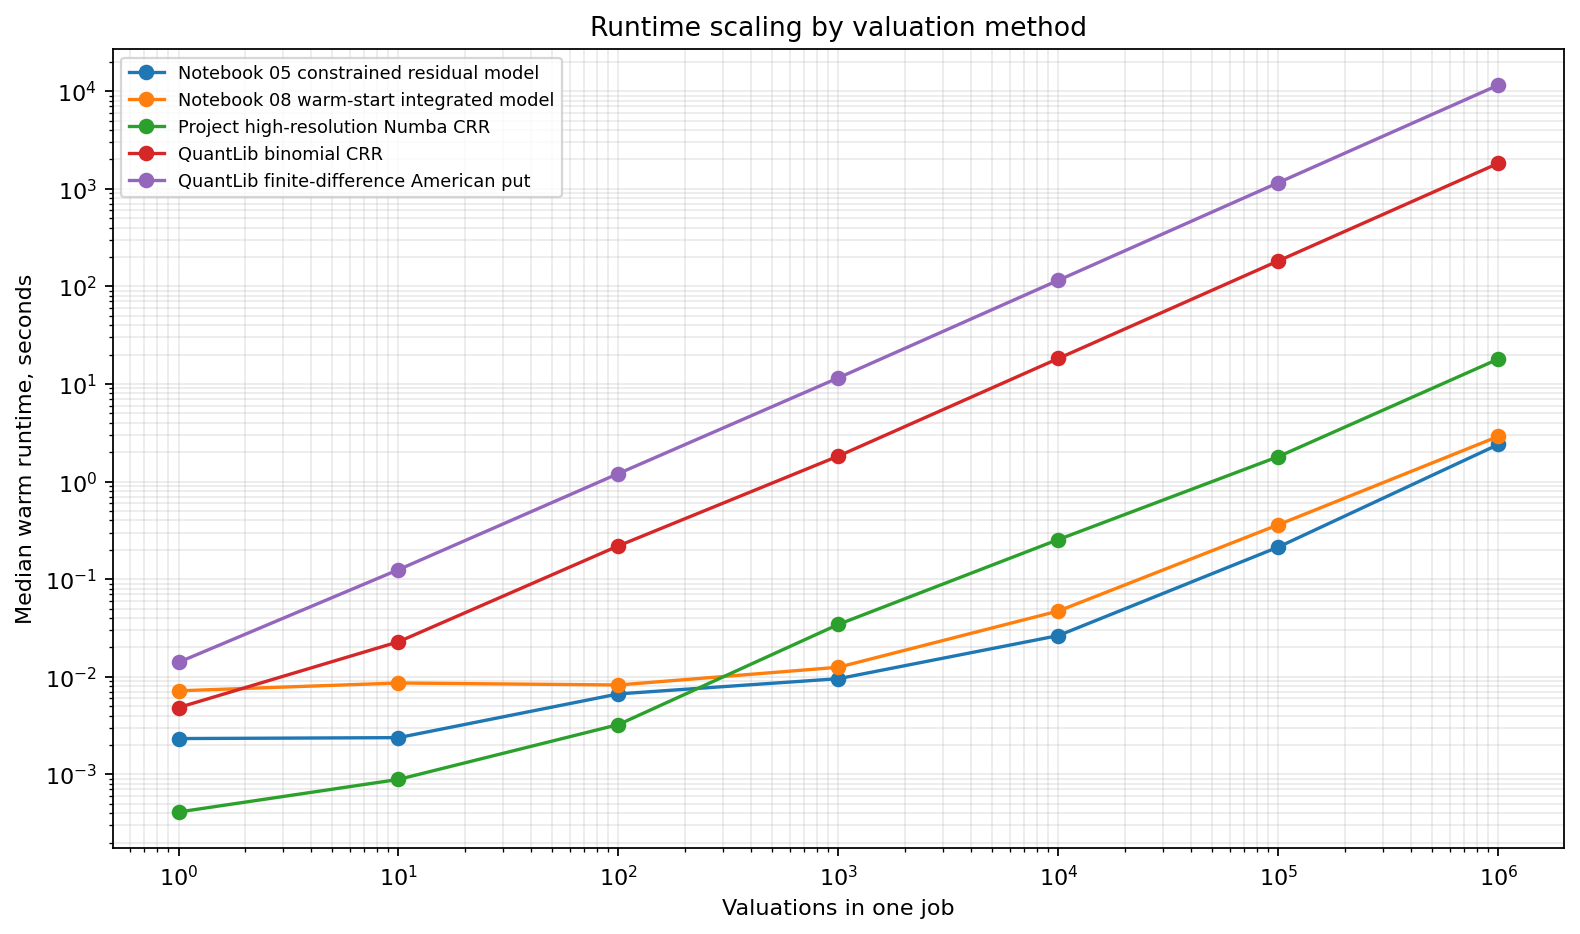

business_speedup_vs_crr


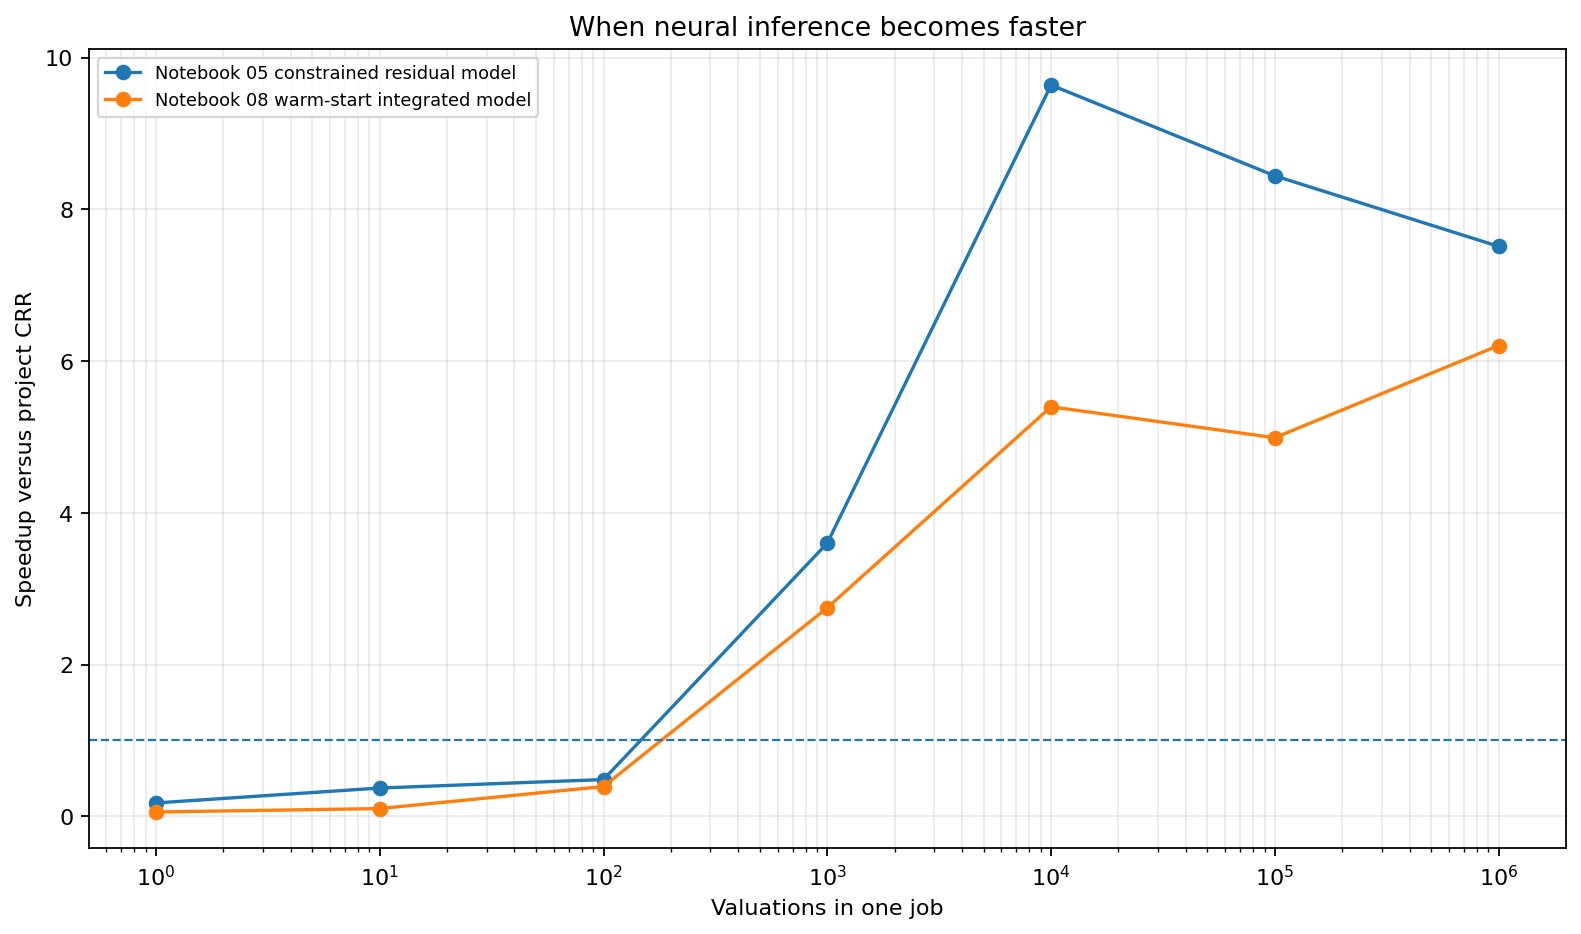

business_lifecycle_break_even


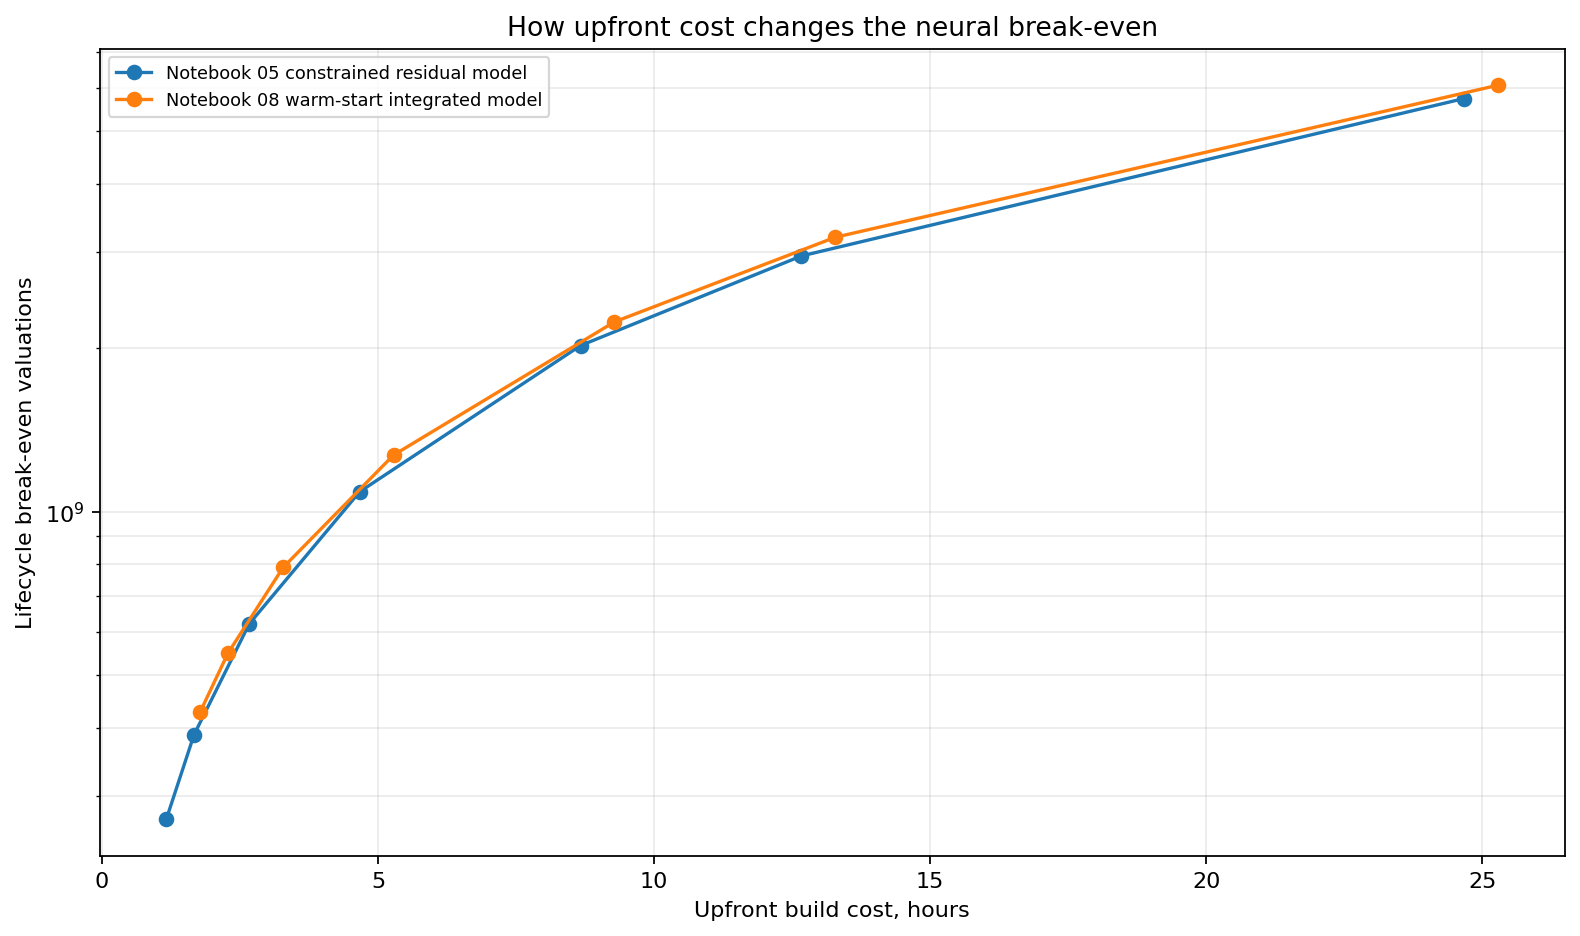

business_workload_scenarios


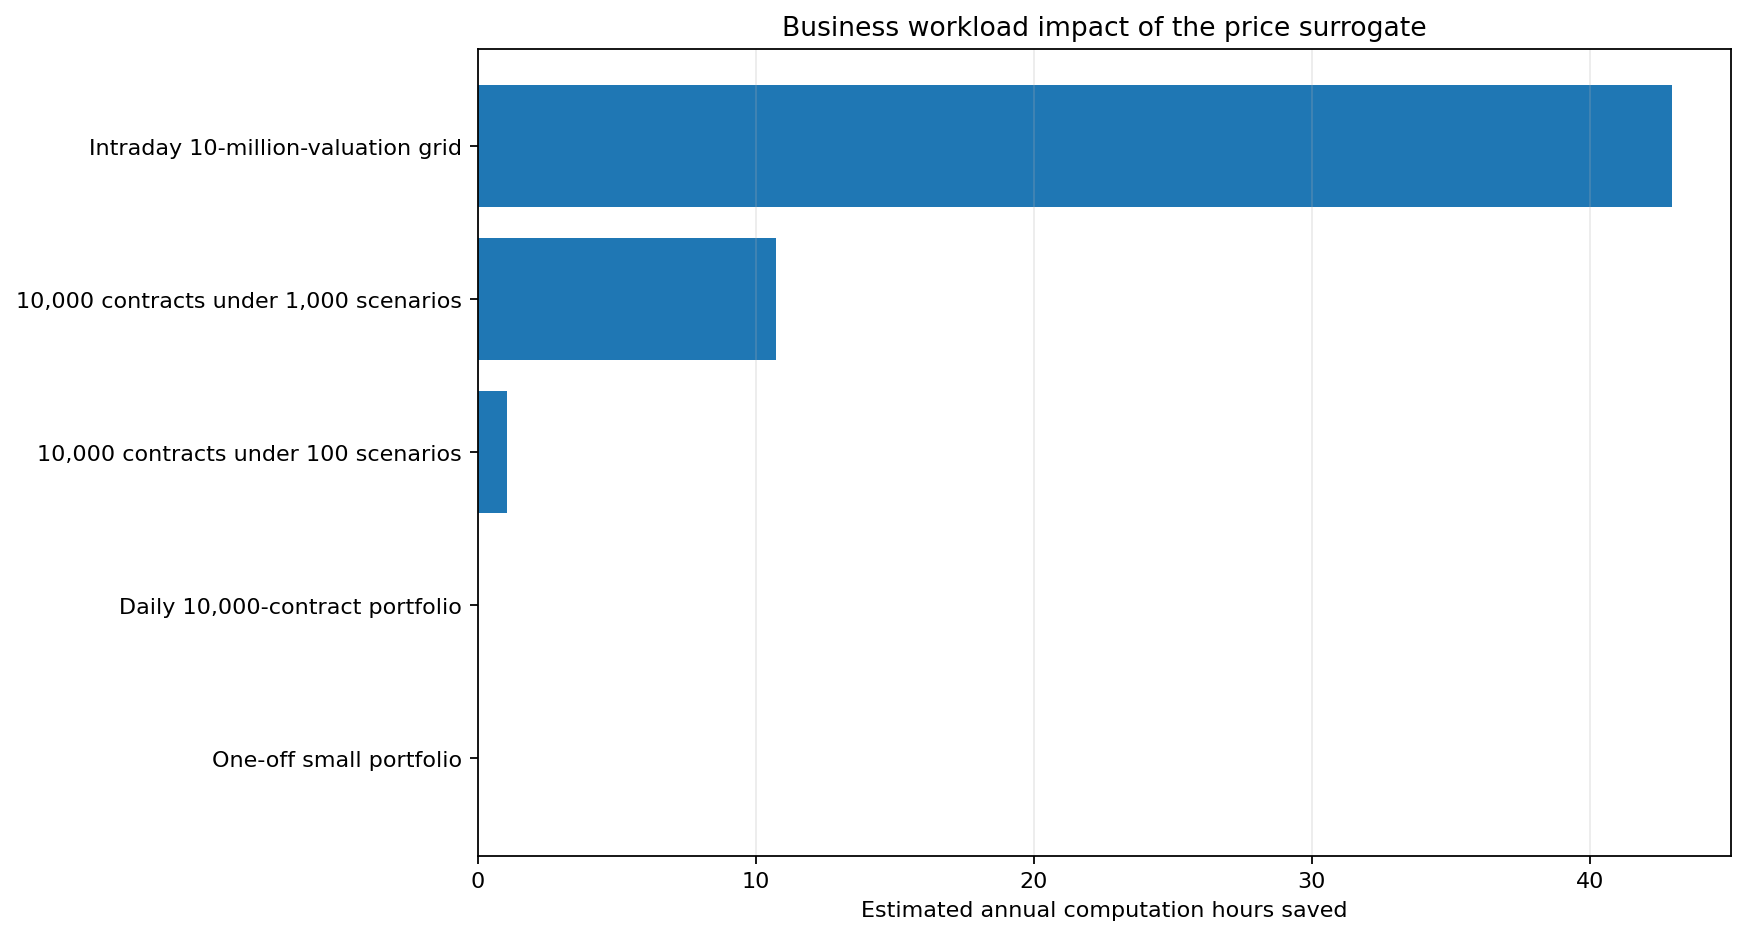

In [23]:
display(
    pd.Series(
        research_question_7_summary,
        name="Research Question 7",
    )
)
display(Markdown(business_case_markdown))

for chart_name, chart_path in (
    business_case_chart_paths.items()
):
    print(chart_name)
    display(
        Image(filename=str(chart_path))
    )

### Plain-language answer to RQ7

Deep learning does not make business sense merely because it can reproduce CRR prices. It makes sense when all of the following conditions hold:

1. the contracts remain inside the validated parameter domain;
2. the pricing rule and payoff structure are stable;
3. the workload contains thousands or millions of repeated valuations;
4. the approximation error is acceptable for the intended use;
5. cumulative time savings are large enough to repay label-generation, training, validation, and maintenance cost.

For one-off valuations, small portfolios, changed contract assumptions, or out-of-domain inputs, the numerical method remains the better choice.

### 10.6 Business-case validation

The business-case gate verifies that the core runtime methods, cold and warm measurements, fitted curves, crossover tables, up-front scenarios, lifecycle calculations, workload scenarios, and charts are all present.

In [24]:
display(business_case_readiness_audit)

if not business_case_readiness_audit[
    "valid"
].astype(bool).all():
    raise RuntimeError(
        "Business-case readiness gate failed."
    )

print("Business-case readiness gate: PASS")

,check,valid,details
0,core_runtime_methods_complete,True,"methods=['notebook05_constrained_residual', 'n..."
1,cold_and_warm_timings_present,True,"timing_modes=['cold', 'warm']"
2,accuracy_conditioning_complete,True,"methods=['notebook05_constrained_residual', 'n..."
3,runtime_curves_complete,True,"pairs=[('notebook05_constrained_residual', 'co..."
4,operational_crossover_complete,True,"models=['notebook05_constrained_residual', 'no..."
5,upfront_cost_scenarios_complete,True,"deployments=['full_research_programme', 'noteb..."
6,lifecycle_break_even_complete,True,"models=['notebook05_constrained_residual', 'no..."
7,business_workload_scenarios_complete,True,rows=10
8,research_question_7_answer_complete,True,Does neural inference provide a meaningful spe...
9,business_case_charts_complete,True,"charts=['business_lifecycle_break_even', 'busi..."


Business-case readiness gate: PASS


### Interpretation

The business-case validation passes. The speed, crossover, lifecycle, and workload claims are supported by complete tables and charts rather than by one isolated runtime number.

### 10.7 Save the business-case evidence

The runtime, crossover, lifecycle, workload, recommendation, and chart outputs are exported as a separate practical-evaluation package.

In [25]:
business_case_tables = {
    "runtime_scaling": runtime_scaling,
    "accuracy_speed_tradeoff": (
        accuracy_speed_tradeoff
    ),
    "runtime_curves": runtime_curves,
    "operational_crossover": (
        operational_crossover
    ),
    "upfront_cost_inventory": (
        upfront_cost_inventory
    ),
    "upfront_cost_scenarios": (
        upfront_cost_scenarios
    ),
    "lifecycle_break_even": (
        lifecycle_break_even
    ),
    "business_case_scenarios": (
        business_case_scenarios
    ),
    "business_case_recommendations": (
        business_case_recommendations
    ),
    "business_case_readiness_audit": (
        business_case_readiness_audit
    ),
}

business_case_export_paths = {}
for name, table in business_case_tables.items():
    path = (
        BUSINESS_CASE_OUTPUT_DIR
        / f"{name}.csv"
    )
    table.to_csv(path, index=False)
    business_case_export_paths[name] = str(path)

runtime_environment_path = (
    BUSINESS_CASE_OUTPUT_DIR
    / "runtime_environment.json"
)
runtime_environment_path.write_text(
    json.dumps(
        _json_safe(runtime_environment),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
business_case_export_paths[
    "runtime_environment"
] = str(runtime_environment_path)

rq7_path = (
    BUSINESS_CASE_OUTPUT_DIR
    / "research_question_7_summary.json"
)
rq7_path.write_text(
    json.dumps(
        _json_safe(
            research_question_7_summary
        ),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
business_case_export_paths[
    "research_question_7_summary"
] = str(rq7_path)

pd.Series(
    business_case_export_paths,
    name="exported_path",
)

runtime_scaling                  D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
accuracy_speed_tradeoff          D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
runtime_curves                   D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
operational_crossover            D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
upfront_cost_inventory           D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
upfront_cost_scenarios           D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
lifecycle_break_even             D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
business_case_scenarios          D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
business_case_recommendations    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
business_case_readiness_audit    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
runtime_environment              D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
research_question_7_summary      D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
Name

## 11. Visual summary of the project

The final charts present the main evidence at a glance:

- static pricing error;
- exercise-decision F1;
- OOD deterioration;
- runtime comparison;
- Longstaff–Schwartz held-out error;
- business-case scaling, speedup, lifecycle break-even, and workload impact.

The charts support the tables; they do not replace the numerical conclusions.

Static pricing accuracy


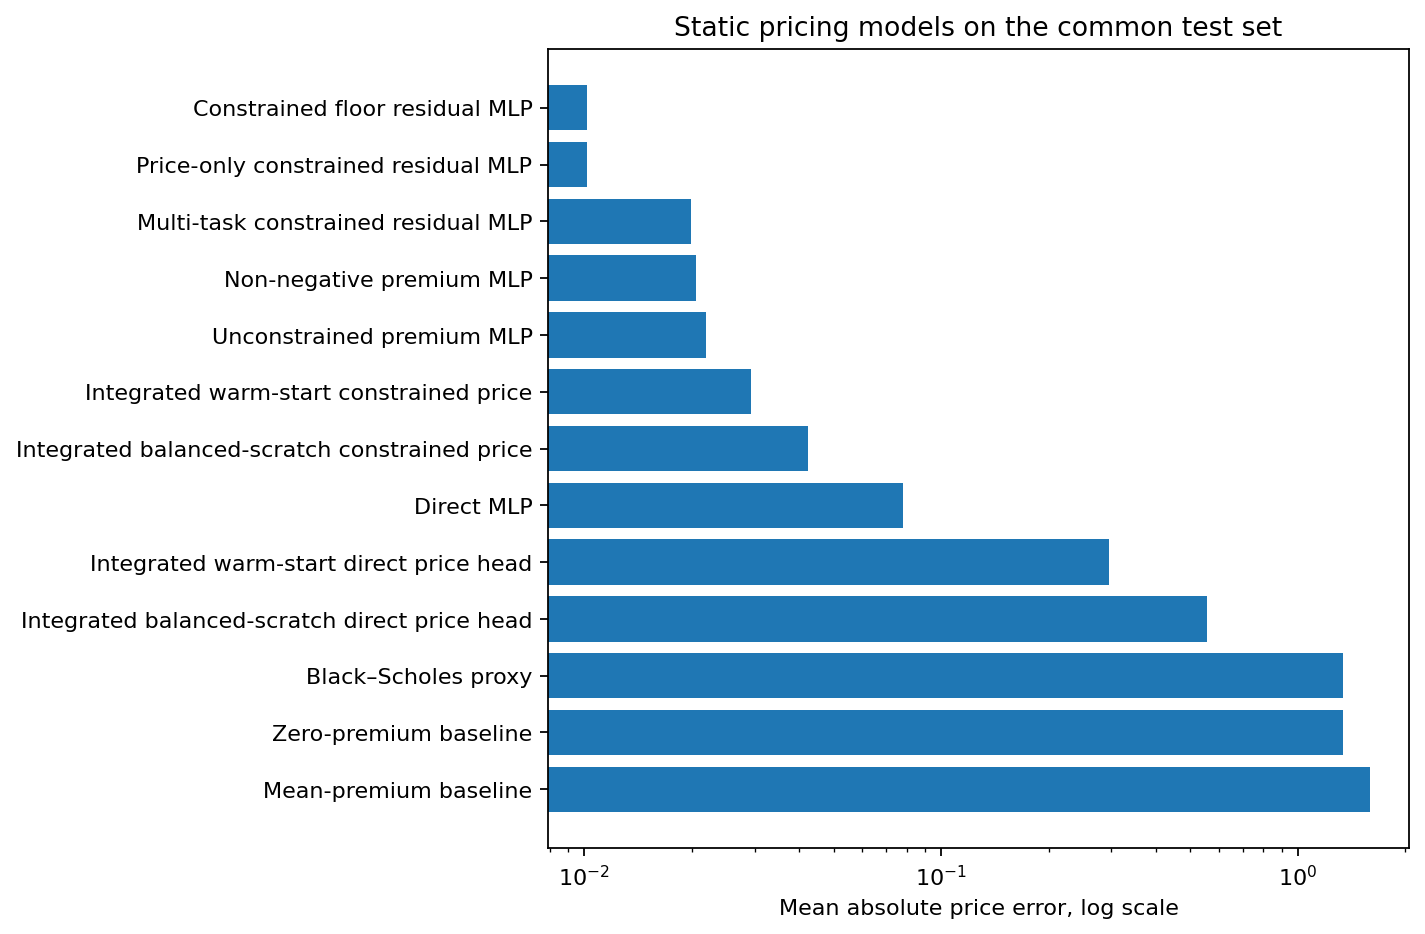

Exercise-decision accuracy


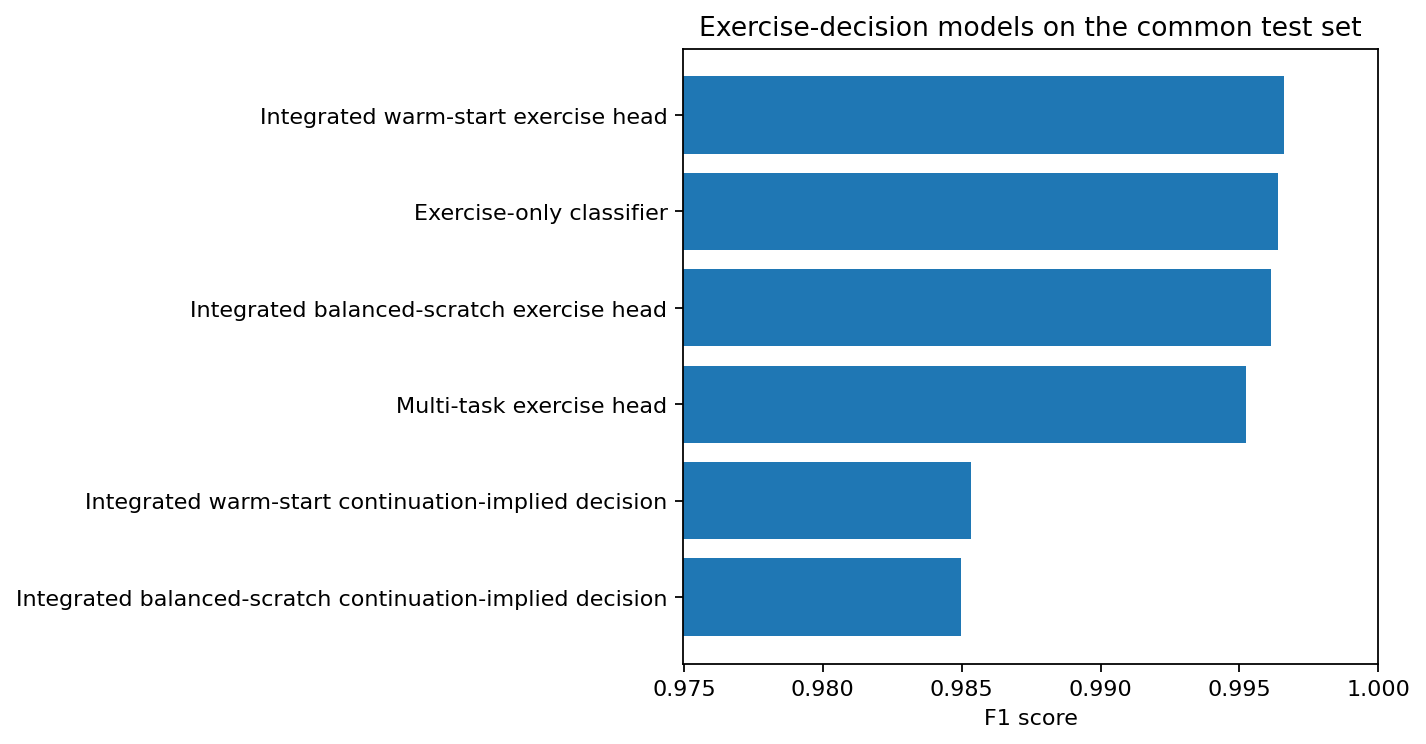

Out-of-domain deterioration


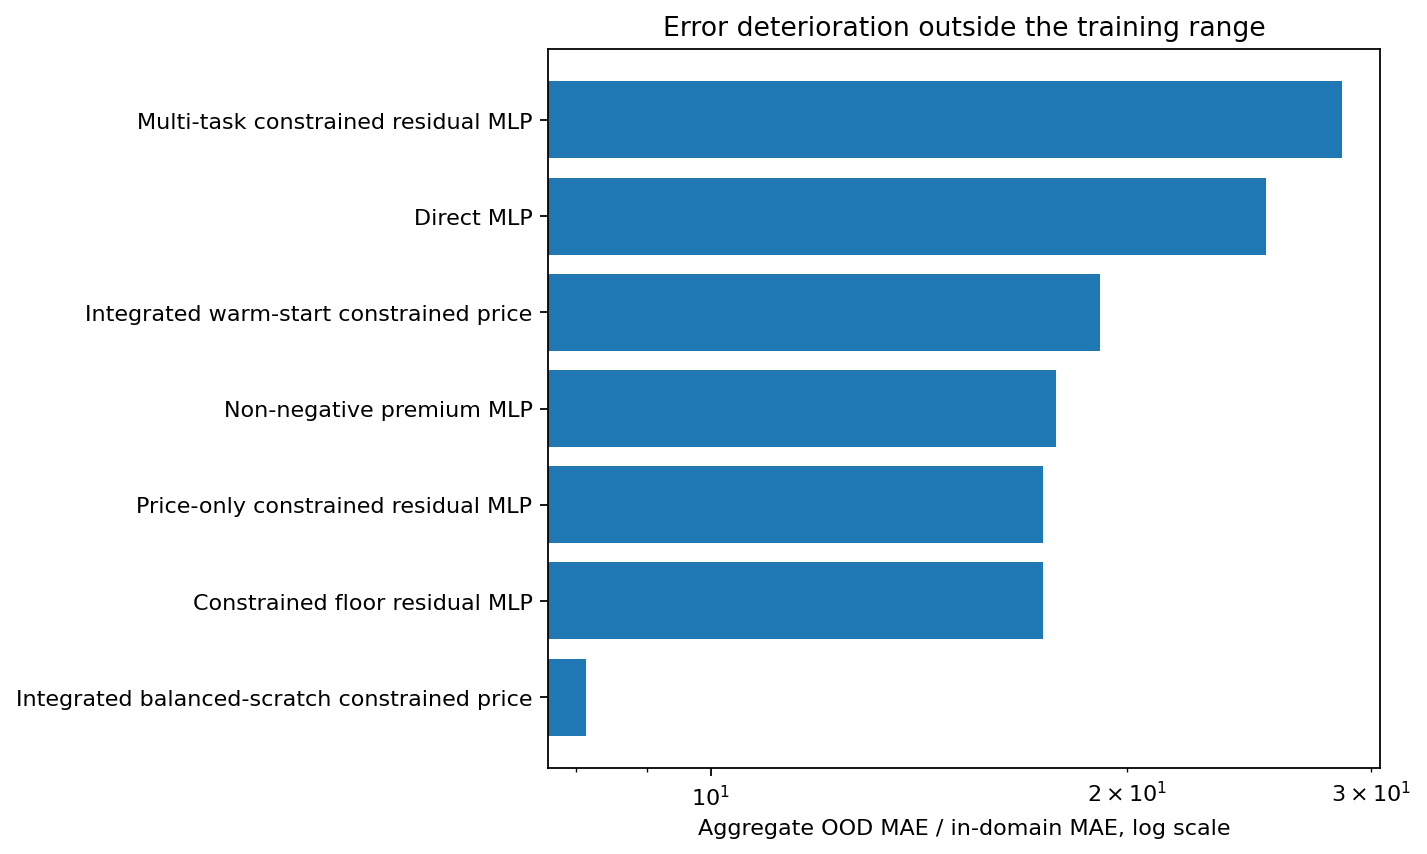

Static neural inference versus CRR


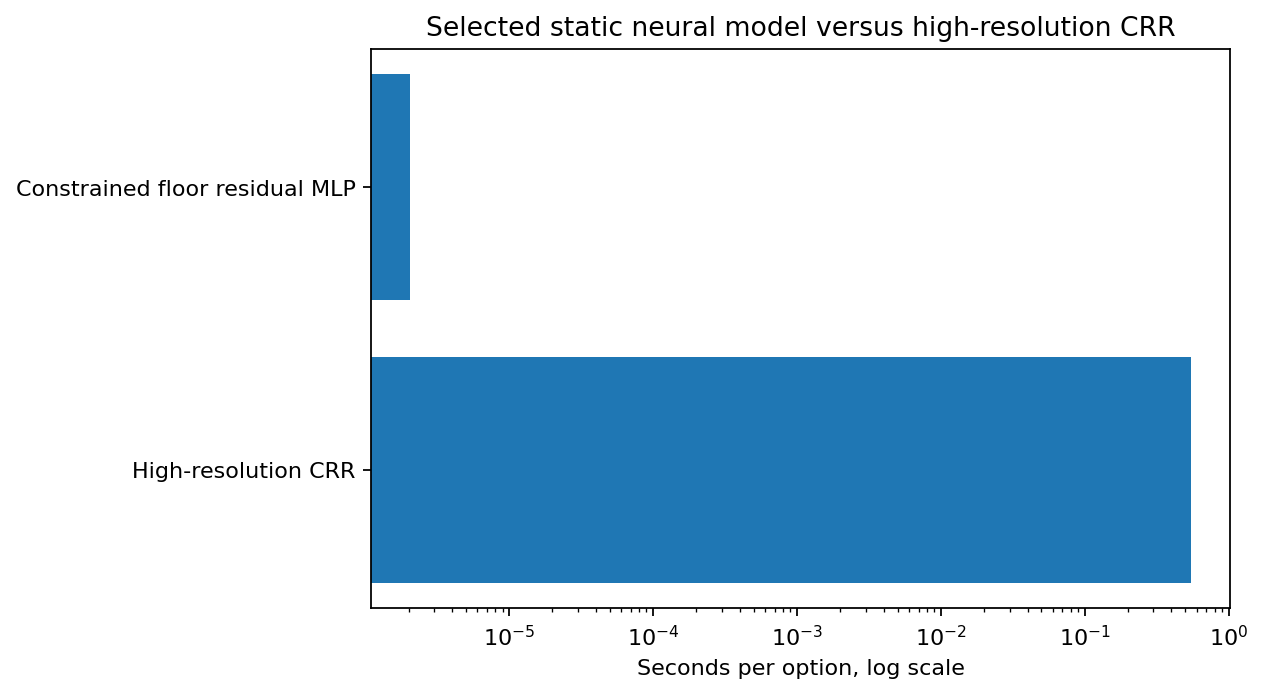

Path-based pricing


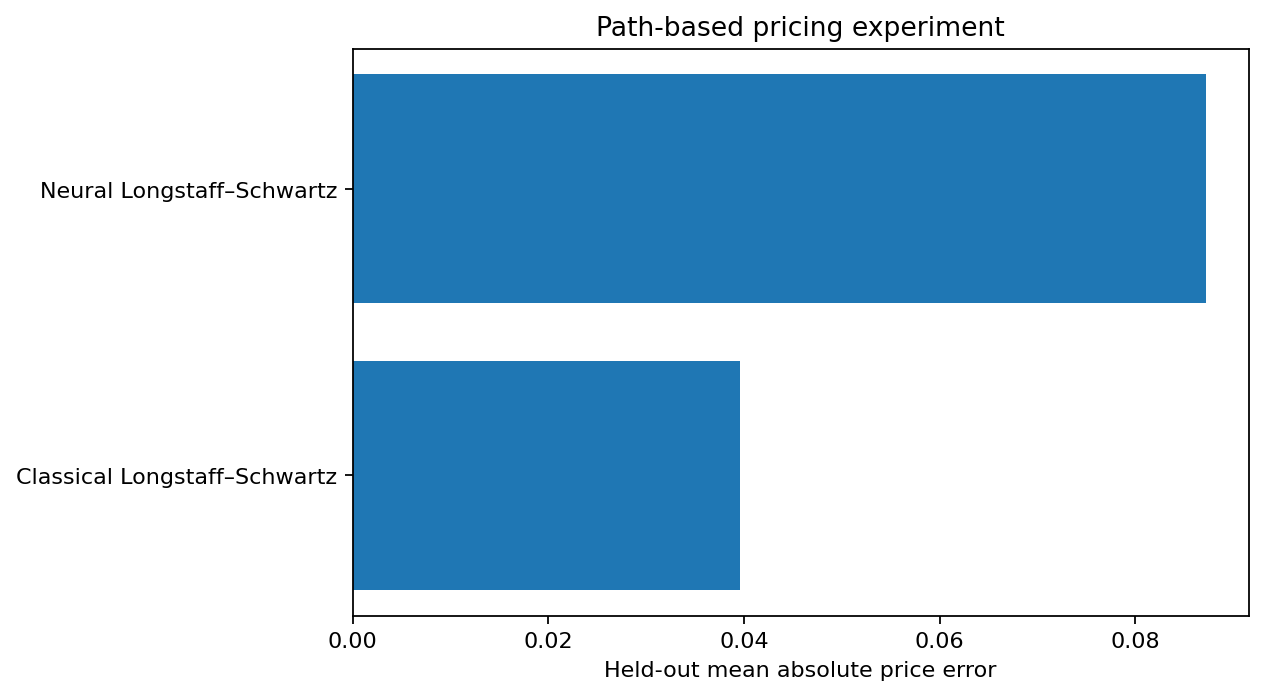

Business-case runtime scaling


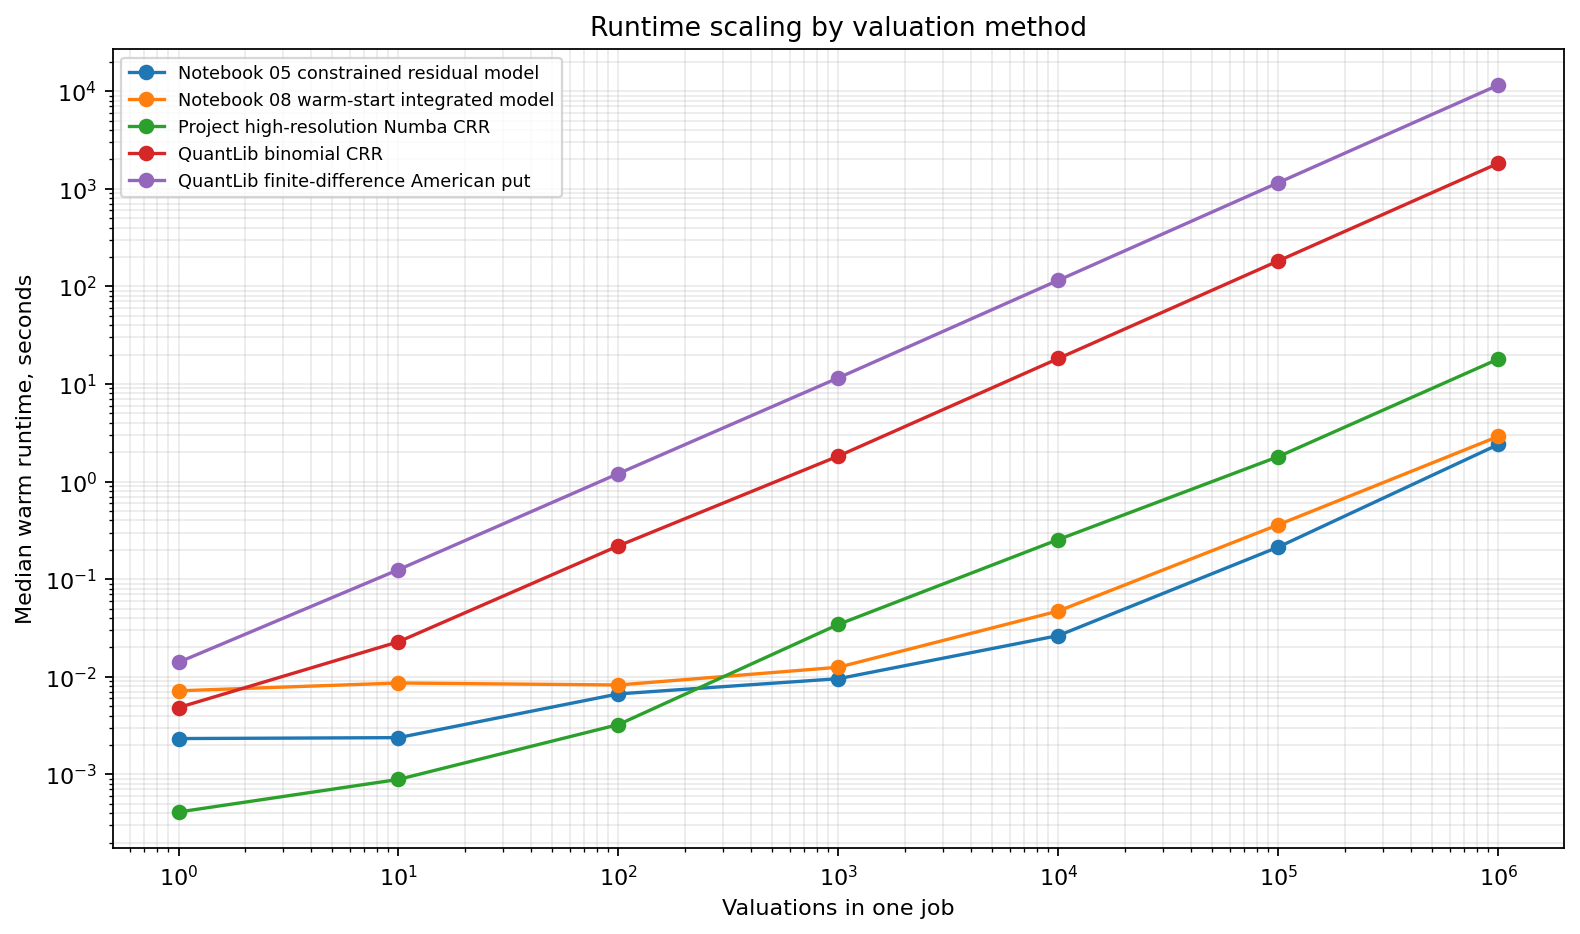

Neural speedup versus CRR


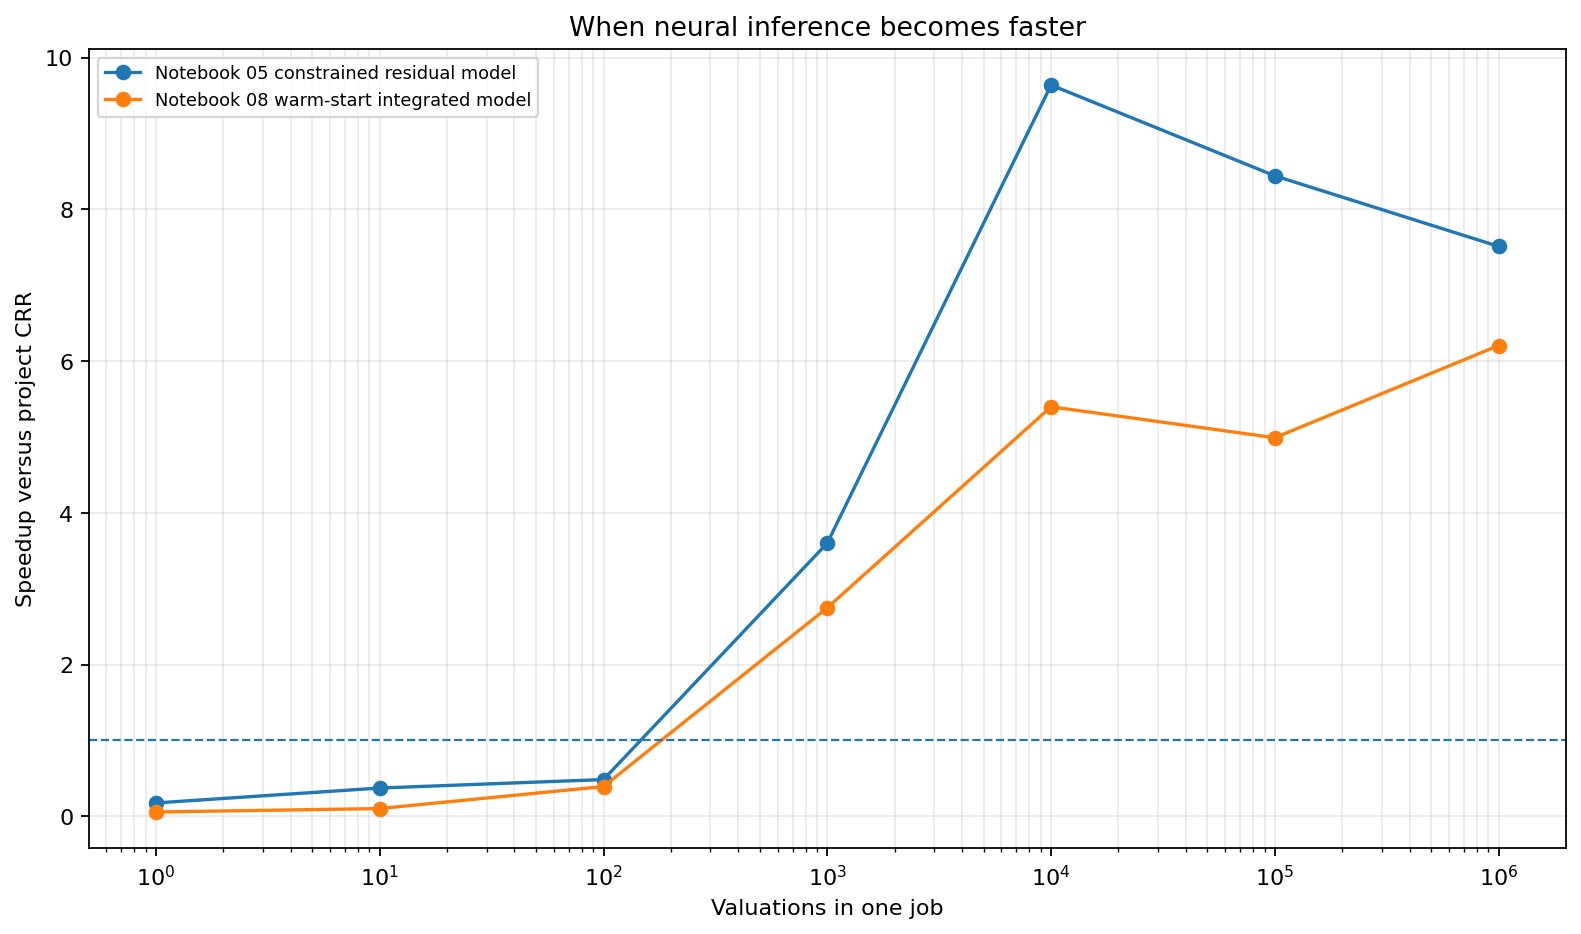

Lifecycle break-even


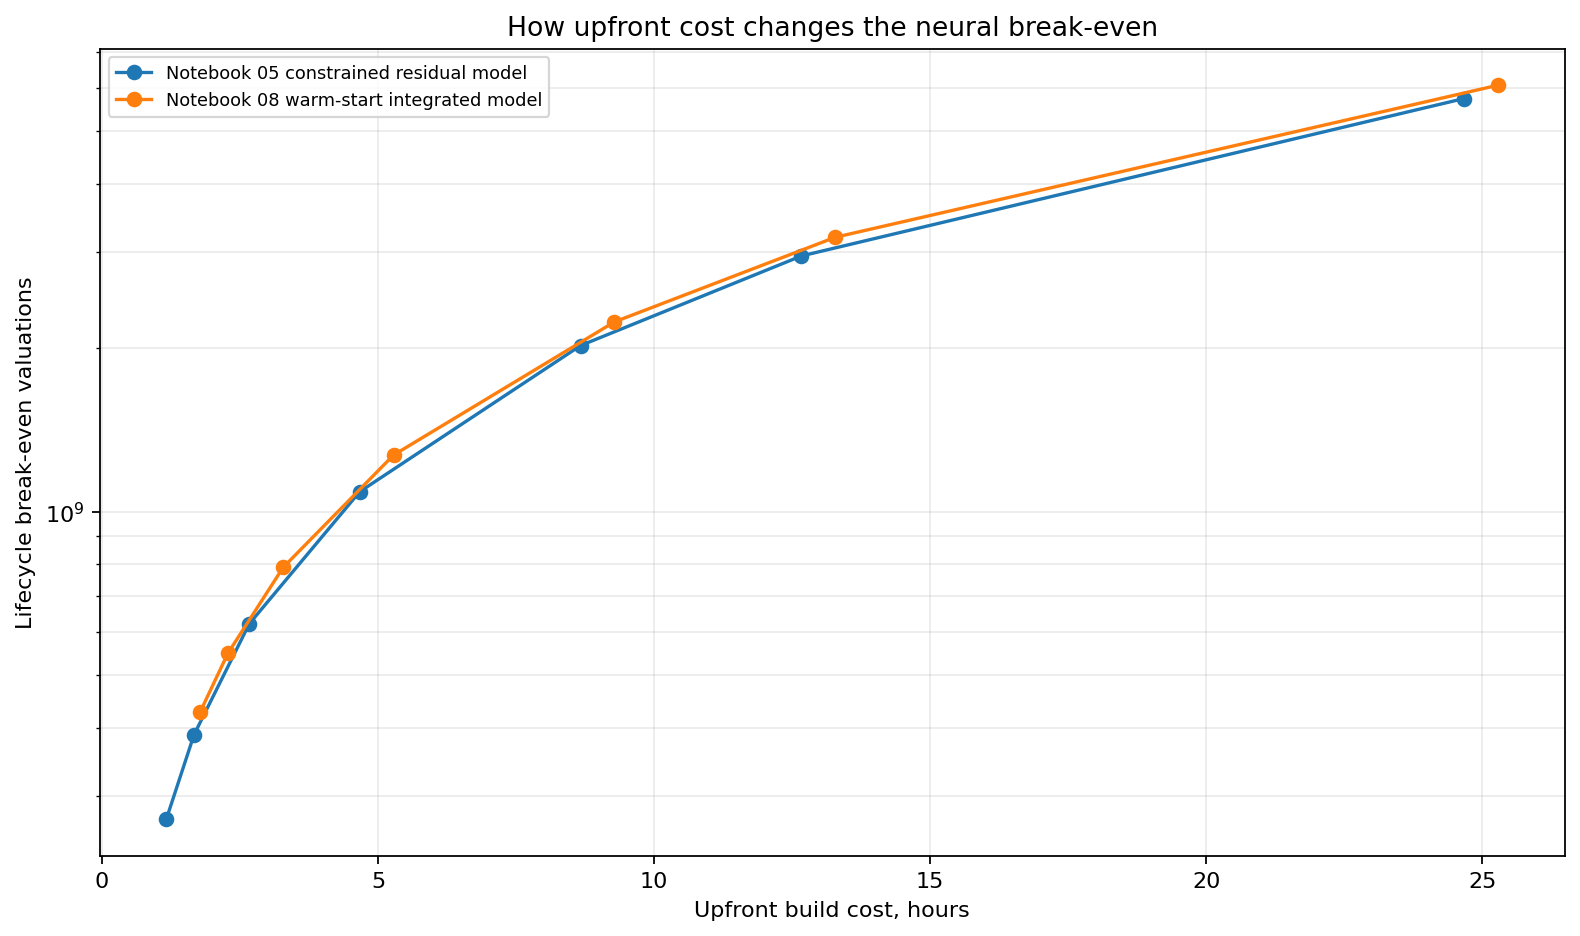

Business workload scenarios


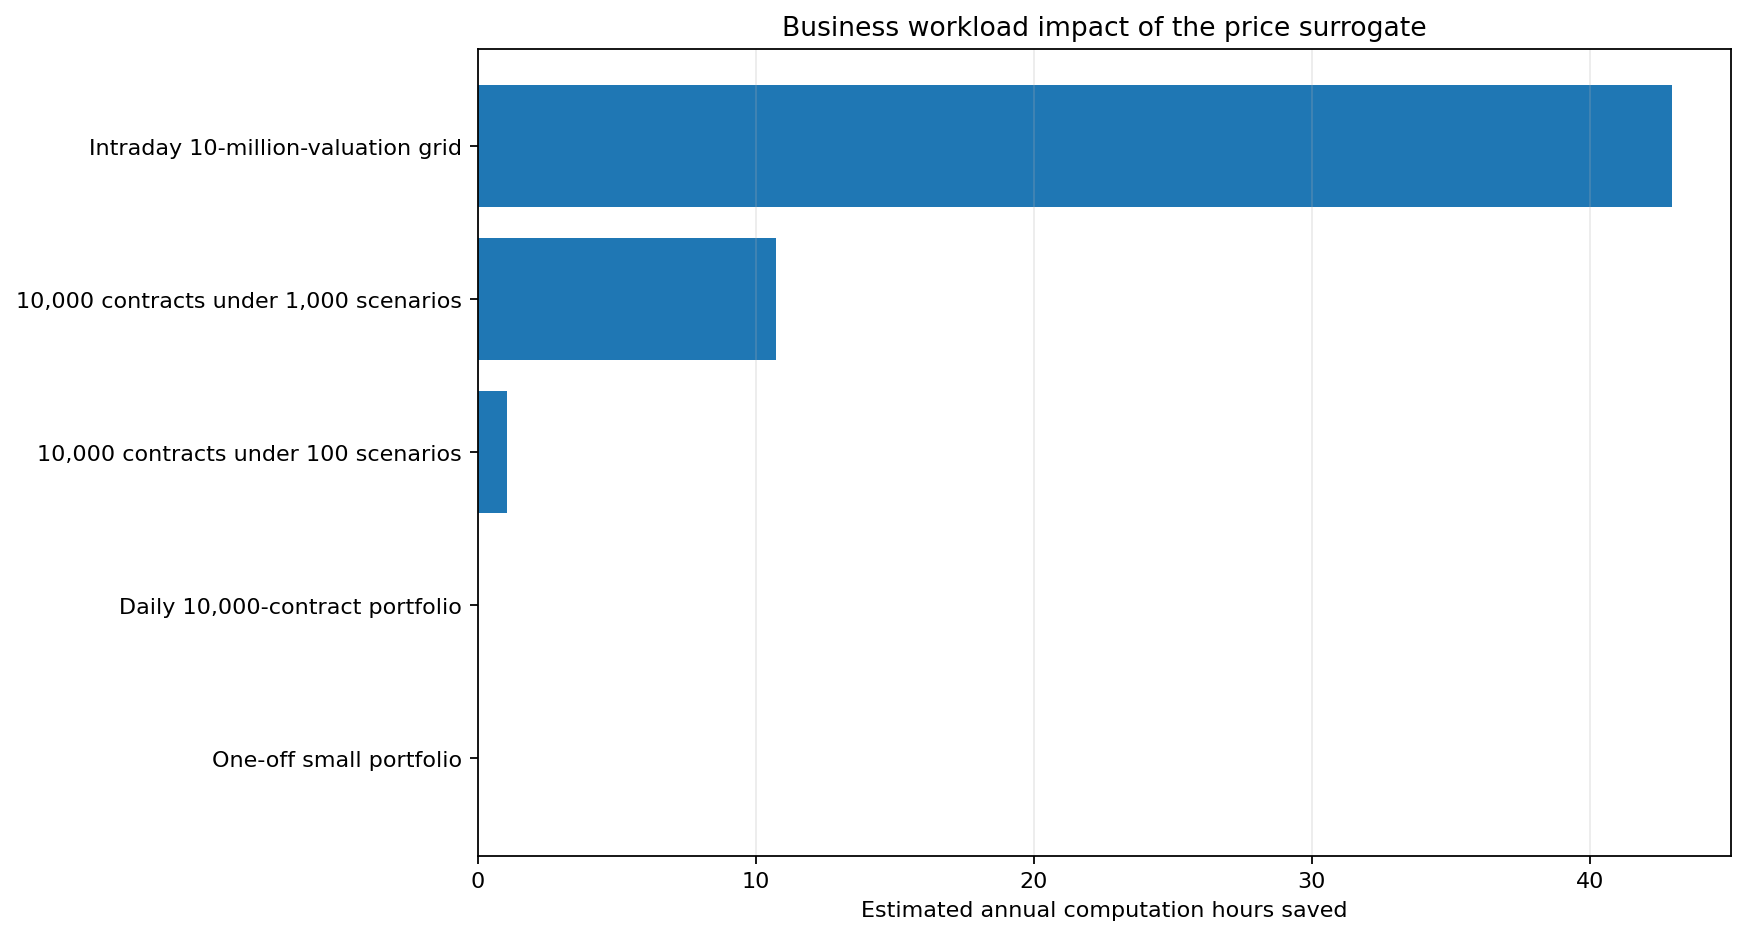

In [26]:
FINAL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "final_evaluation"
    / "final"
)
FINAL_CHART_DIR = FINAL_OUTPUT_DIR / "charts"

final_chart_paths = generate_final_charts(
    FINAL_CHART_DIR,
    static_model_metrics=static_model_metrics,
    exercise_model_metrics=exercise_model_metrics,
    static_ood_model_summary=(
        static_ood_model_summary
    ),
    runtime_comparison=runtime_comparison,
    lsm_heldout_pricing=phase_5_6_results[
        "lsm_heldout_pricing"
    ],
)

# The business-case charts are part of the final evidence package.
FINAL_CHART_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for chart_name, source_path in business_case_chart_paths.items():
    source_path = Path(source_path)
    destination_path = (
        FINAL_CHART_DIR
        / source_path.name
    )

    if source_path.resolve() != destination_path.resolve():
        copy2(
            source_path,
            destination_path,
        )

    final_chart_paths[
        chart_name
    ] = destination_path

chart_titles = {
    "static_pricing_mae": "Static pricing accuracy",
    "exercise_f1": "Exercise-decision accuracy",
    "ood_deterioration": "Out-of-domain deterioration",
    "runtime_comparison": "Static neural inference versus CRR",
    "lsm_heldout_mae": "Path-based pricing",
    "business_runtime_scaling": "Business-case runtime scaling",
    "business_speedup_vs_crr": "Neural speedup versus CRR",
    "business_lifecycle_break_even": "Lifecycle break-even",
    "business_workload_scenarios": "Business workload scenarios",
}

for chart_name, chart_path in final_chart_paths.items():
    print(chart_titles.get(chart_name, chart_name))
    display(Image(filename=str(chart_path)))

## 12. Task-specific model selection and the role of Notebook 08

There is no universal preferred model because the project contains genuinely different tasks.

The recommendation table distinguishes:

- the most accurate static price;
- the highest measured exercise F1;
- the preferred exercise-only deployment;
- one integrated model for price and exercise;
- the preferred path-based method;
- the lowest absolute OOD error;
- repeated large-batch pricing.

Notebook 08 should therefore be interpreted as a **combined deployment option**, not as an automatic replacement for the best specialists.

In [27]:
phase_7_8_results = run_phase_7_8_pre_export(
    artifact_audit=artifact_audit,
    package_coherence=package_coherence,
    static_prediction_alignment=(
        static_prediction_alignment
    ),
    static_field_alignment=static_field_alignment,
    static_model_metrics=static_model_metrics,
    static_financial_consistency=(
        static_financial_consistency
    ),
    exercise_model_metrics=exercise_model_metrics,
    exercise_boundary_metrics=(
        exercise_boundary_metrics
    ),
    static_ood_model_summary=(
        static_ood_model_summary
    ),
    lsm_heldout_pricing=phase_5_6_results[
        "lsm_heldout_pricing"
    ],
    lsm_coverage=phase_5_6_results[
        "lsm_coverage"
    ],
    runtime_comparison=runtime_comparison,
    hypothesis_decisions=hypothesis_decisions,
    chart_paths=final_chart_paths,
)

task_recommendations = phase_7_8_results[
    "task_recommendations"
]
integrated_model_tradeoff = phase_7_8_results[
    "integrated_model_tradeoff"
]
project_findings = phase_7_8_results[
    "project_findings"
]
project_limitations = phase_7_8_results[
    "project_limitations"
]
final_results_summary = phase_7_8_results[
    "final_results_summary"
]
final_conclusion_markdown = phase_7_8_results[
    "final_conclusion_markdown"
]
pre_export_readiness_audit = phase_7_8_results[
    "pre_export_readiness_audit"
]

display(task_recommendations)
display(integrated_model_tradeoff)
display(project_findings)


# Add the measured economics to the final interpretation.
business_finding = pd.DataFrame(
    [
        {
            "topic": "Business case",
            "finding": (
                research_question_7_summary[
                    "marginal_speed_answer"
                ]
            ),
            "meaning": (
                research_question_7_summary[
                    "business_answer"
                ]
            ),
        }
    ]
)
project_findings = pd.concat(
    [project_findings, business_finding],
    ignore_index=True,
)

business_limitations = pd.DataFrame(
    [
        {
            "limitation": (
                "Historical upfront timing"
            ),
            "effect": (
                "Where label-generation or training "
                "wall-clock time was not retained, "
                "lifecycle break-even is reported as "
                "an explicit scenario range rather "
                "than one measured point."
            ),
        },
        {
            "limitation": (
                "Benchmark portability"
            ),
            "effect": (
                "Operational crossover depends on "
                "hardware, threading, batch size, "
                "library version, and whether a "
                "service is already warm."
            ),
        },
    ]
)
project_limitations = pd.concat(
    [
        project_limitations,
        business_limitations,
    ],
    ignore_index=True,
)

final_results_summary[
    "research_question_7"
] = research_question_7_summary
final_results_summary[
    "business_case_status"
] = "complete"
final_results_summary[
    "overall_answer"
] = (
    "Deep learning is not justified merely because "
    "the models can approximate CRR. It earns a "
    "practical role only for repeated in-domain "
    "valuation above the measured operational "
    "crossover and, over the model lifecycle, above "
    "the break-even volume required to repay label "
    "generation and training. Numerical pricing "
    "remains preferable for one-off, changing, or "
    "out-of-domain work."
)

final_conclusion_markdown = (
    final_conclusion_markdown.rstrip()
    + "\n\n"
    + business_case_markdown.strip()
    + "\n"
)

display(business_case_recommendations)

,task,recommended_model,source_notebook,primary_metric,primary_value,reason,tradeoff
0,Most accurate static price,Constrained floor residual MLP,05,price_mae,0.010187,Lowest error on the aligned common test set an...,Produces a price only; it does not provide an ...
1,Most accurate exercise decision,Integrated warm-start exercise head,08,f1,0.996603,Best exercise-decision F1 score on the aligned...,"This is the integrated warm-start model, so it..."
2,Exercise-only deployment,Exercise-only classifier,06,f1,0.996393,Use the dedicated Notebook 06 classifier when ...,Its F1 may be marginally below the integrated ...
3,One model for both price and exercise,Integrated warm-start deployment model,08,price_mae_and_exercise_f1,0.996603,Returns a constrained price with MAE 0.029391 ...,Its price is less accurate and its inference i...
4,Path-based valuation,classical_lsm_price,07,heldout_price_mae,0.039594,Lowest held-out contract-level pricing error i...,Path simulation remains much slower than stati...
5,Lowest absolute error outside the training range,Constrained floor residual MLP,05,aggregate_ood_normalized_mae,0.001770,Lowest average absolute pricing error across t...,The error still rises materially relative to i...
6,Repeated large-batch pricing,Constrained floor residual MLP,05,speedup_vs_high_resolution_crr,266185.976876,"About 266,186 times faster than the high-resol...",The measured speedup is hardware- and batch-si...


,dimension,specialist_model,specialist_value,integrated_value,comparison,interpretation
0,Pricing error,Constrained floor residual MLP,0.010187,0.029391,Integrated error is 2.89 times larger.,The combined model does not replace the specia...
1,Exercise F1,Exercise-only classifier,0.996393,0.996603,Integrated minus specialist = 0.000209.,The direct integrated decision is extremely cl...
2,Financial lower-bound violations,Constrained floor residual MLP,0.000000,0.000000,Both authoritative constrained prices have zer...,The integrated price keeps the same structural...
3,Inference throughput,Constrained floor residual MLP,484867.762053,NaN,Integrated throughput is nan% of the specialist.,Several outputs from one network cost addition...
4,Continuation-implied decision F1,Exercise-only classifier,0.996393,0.985347,Continuation-implied minus specialist = -0.011...,The value-of-waiting output is informative but...


,topic,finding,meaning
0,Direct approximation,The direct neural model reduces normalized MAE...,A neural surrogate can learn the American earl...
1,Best static price,The constrained residual model has price MAE 0...,Learning only the value above a known lower bo...
2,Financial consistency,The selected constrained price has zero lower-...,Embedding a minimum valid price in the output ...
3,Exercise decision,The specialist classifier reaches F1=0.996393.,A dedicated decision model remains the best op...
4,Combined model,The integrated model reaches price MAE 0.02939...,"It is a strong one-model compromise, but it do..."
5,Outside the training range,Every eligible static model has aggregate out-...,Excellent interpolation does not imply dependa...
6,Path-based experiment,"Classical Longstaff–Schwartz MAE is 0.039594, ...",The neural continuation policy did not justify...
7,Speed,"The selected static model is about 266,186 tim...",The practical value of the surrogate appears w...
8,Hypotheses,H1: Supported; H2: Supported; H3: Supported; H...,"The evidence supports approximation, residual ..."


,situation,recommended_method,reason,measured_threshold
0,One-off valuation or small portfolio,"Numerical CRR, finite difference, or QuantLib","No model-building cost is justified, and cold-...",NaN
1,Repeated in-domain price-only workload,Notebook 05 constrained residual model,It is the most accurate static pricer and has ...,1.0
2,Repeated in-domain price and exercise workload,Notebook 08 warm-start integrated model,It returns both outputs in one call and is fas...,246.0
3,Contract outside the validated neural domain,High-resolution numerical method,All static neural models deteriorate materiall...,NaN
4,Large scenario grids or portfolio stress testing,Neural surrogate inside the domain with numeri...,This is the workload where a small marginal in...,1000000.0
5,"New payoff, exercise rule, or model assumptions",Numerical implementation first,A neural surrogate only reproduces the pricing...,NaN


### Interpretation — no universal winner

The task-specific table resolves the apparent conflict between specialist and integrated models:

- Notebook 05 is the clear pricing specialist.
- Notebook 08 has the highest measured exercise F1, but the gain over the Notebook 06 classifier is only 0.000210. The classifier remains the narrower exercise-only deployment.
- Notebook 08 is the preferred one-model compromise when both outputs are required.
- Classical LSM is the preferred path-based method.

Two technical caveats in the generated tables should not drive the written conclusion:

1. The **266,186×** speed ratio compares a per-contract CRR timing from the cross-family runtime inventory with heavily batched static inference. It is retained as a recorded ratio, but the dedicated scaling benchmark's approximately **6–8×** large-batch speedup is the more credible deployment headline.
2. The integrated-throughput row in the trade-off table contains `NaN` because the earlier cross-table lookup did not resolve that runtime entry. The dedicated business benchmark supplies the valid comparison: at one million valuations, Notebook 08 takes approximately 2.90 seconds versus 2.40 seconds for Notebook 05.

## 13. Relationship with the literature and final synthesis

The project does not claim an exact architectural reproduction of the supplied articles. It reproduces and extends their central research propositions.

| Literature direction | Relationship to this project |
|---|---|
| **Ke and Yang (2019)** | Supports the use of dense feed-forward networks and the finding that greater architectural complexity does not automatically improve option-pricing performance. |
| **Elbayed and Qadi El Idrissi (2025)** | The direct MLP reproduces the basic idea of learning a theoretical pricing function, but the project moves from European to American puts because American valuation has a stronger computational motivation. |
| **Pimentel et al. (2026); Zouaoui and Naas (2023)** | Their recurrent architectures are appropriate when the input contains genuine time sequences. This project uses one static five-variable contract state, so an LSTM or GRU would introduce artificial sequence structure. |
| **Pu (2021)** | The supervised American-option experiment and mandatory OOD testing follow the practical distinction between strong interpolation and unreliable extrapolation. |
| **Ding, Lu, and Cheung (2025)** | Their compressed implied-volatility-surface representation identifies a credible future extension. The current constant-volatility design is intentionally narrower so target formulation and financial constraints can be isolated. |
| **Longstaff and Schwartz (2001)** | Notebook 07 reproduces continuation-value regression and tests a neural replacement. The classical method remains superior under the tested design. |

The literature synthesis reinforces the main project result:

> **The useful innovation is not the most complicated network. It is the combination of a justified computational use case, a controlled synthetic benchmark, financially structured targets, strict leakage controls, and honest negative results where added neural complexity does not earn its place.**

The next cell renders the generated project conclusion from the consolidated evidence.

# Final Project Conclusion

## The Main Answer

The project does not produce one model that is best at everything. Instead, it establishes a clear division of work across different pricing and exercise-related tasks.

| Task                               | Preferred model                                             | Interpretation                                                            |
| ---------------------------------- | ----------------------------------------------------------- | ------------------------------------------------------------------------- |
| Most accurate static price         | **Constrained floor residual MLP**                          | Lowest pricing error and zero financial lower-bound violations            |
| Highest measured exercise F1       | **Integrated warm-start exercise head**                     | Marginally higher F1 than the specialist classifier                       |
| Exercise-only deployment           | **Exercise-only classifier from Notebook 06**               | Narrower and more efficient when no price output is required              |
| Combined price and exercise output | **Warm-start integrated deployment model from Notebook 08** | Returns a protected price and an exercise recommendation from one network |
| Path-based valuation               | **Classical Longstaff–Schwartz (`classical_lsm_price`)**    | More accurate, faster, and better calibrated than the neural policy       |

The warm-start integrated model is useful for combined in-domain deployment, but it is not the overall pricing winner. Its pricing error is **2.89 times larger** than that of the constrained specialist model. Its exercise F1 exceeds the specialist classifier by only **0.000209**, which is numerically positive but operationally negligible.

Its value therefore comes from combining several related outputs in one model while keeping the authoritative price above the required financial lower bounds.

---

## What the Experiments Establish

### Static Pricing

The direct neural model already improves substantially on using the European Black–Scholes price as a proxy for an American put.

The larger improvement comes from reformulating the learning problem. Instead of asking the network to relearn the complete option price, the strongest model predicts only the amount above a known minimum valid value:

$$
\max(V_E, I),
$$

where (V_E) is the European value and (I) is intrinsic value.

The constrained residual model is therefore both:

* more accurate than the direct MLP; and
* free of lower-bound violations on the common test set.

This demonstrates that financial structure and target design contribute more value than simply increasing model complexity.

### Exercise Decision

The exercise experiments show that joint learning is possible without materially reducing classification quality, but they do not establish a meaningful advantage from joint learning.

The integrated warm-start exercise head records the highest measured F1 score, but its improvement over the specialist classifier is only **0.000209**. The specialist classifier therefore remains the more efficient choice when only an exercise recommendation is required.

The integrated model becomes preferable when price and exercise information must be produced together. The alternative decision inferred from the estimated continuation value is weaker and should be treated as supporting information rather than the primary exercise recommendation.

### Path-Based Valuation

The path-based experiment produces a different result.

Classical Longstaff–Schwartz is:

* more accurate;
* faster;
* and better in terms of confidence-interval coverage

than the neural continuation policy under the tested implementation.

The neural Longstaff–Schwartz model therefore does not earn a preferred role in the final project. This is an important negative result: adding a neural network to an established numerical method does not automatically improve it.

### Out-of-Domain Performance

All eligible static neural models deteriorate materially when tested outside the range used for training.

The exact deterioration varies by model and stress regime, and an individual out-of-domain set may occasionally appear stable. However, the aggregate conclusion remains unchanged:

> Strong interpolation inside the training domain is not evidence of safe extrapolation.

The validated in-domain range is deliberately broad and covers moneyness, maturity, volatility, interest-rate, and dividend conditions representative of most normal practical applications.

The out-of-domain tests mainly represent:

* extreme moneyness;
* unusually high volatility;
* very long maturities; and
* exceptional risk-free-rate and dividend-yield combinations.

These regimes are more appropriately treated as extreme stress scenarios requiring numerical validation rather than routine operating conditions.

### Computational Performance

After training, the static neural models are substantially faster than repeated high-resolution tree valuation.

This is the strongest practical argument for the surrogate approach. The purpose is not to eliminate the numerical model that generated the reference prices, but to avoid repeating the same expensive numerical calculation millions or billions of times.

---

## Hypothesis Decisions

| Hypothesis                            | Decision          | Primary evidence                                                                                                  |
| ------------------------------------- | ----------------- | ----------------------------------------------------------------------------------------------------------------- |
| **H1 — Direct pricing approximation** | **Supported**     | Common-test MAE ratio = **0.058341**                                                                              |
| **H2 — Premium decomposition**        | **Supported**     | Selected residual/direct MAE ratio = **0.130322**                                                                 |
| **H3 — Financial constraints**        | **Supported**     | Direct violation rate = **30.812892%**; constrained violation rate = **0%**                                       |
| **H4 — Multi-task exercise learning** | **Not supported** | Notebook 06 multi-task F1 change = **−0.001152**; relative boundary-price MAE improvement = **−51.6000%**         |
| **H5 — Computational acceleration**   | **Supported**     | Selected static neural/CRR marginal-runtime ratio = **3.7567719 × 10⁻⁶**                                          |
| **H6 — Out-of-domain deterioration**  | **Supported**     | All **7 of 7** eligible models have aggregate OOD/in-domain error ratios above 1.25; minimum ratio = **8.127309** |

---

## Final Answer to the Research Question

A financially structured neural network can serve as a highly accurate and computationally efficient surrogate for American put pricing inside a defined parameter domain. The strongest result comes from combining known option structure with residual learning rather than from using the largest or most complicated architecture.

The approach makes practical sense mainly in high-volume environments performing several million comparable valuations per day.

At approximately **4 million calculations per day**, or around **1 billion valuations annually** over 250 operating days:

* the Notebook 05 specialist pricing model saves approximately **4.3 computation hours per year** relative to the already highly optimised project CRR implementation;
* the Notebook 08 integrated price-and-exercise model saves approximately **4.2 computation hours per year**.

On the tested machine, a four-million-valuation calculation falls from roughly **71 seconds** with the project CRR to approximately **10–12 seconds** with the neural models.

The main operational value is therefore not only the total annual machine hours saved. It is the ability to complete large valuation batches approximately six to eight times faster and reduce latency where calculations must be repeated continuously.

Relevant environments include:

* high-frequency and algorithmic trading;
* options market making;
* large brokerage operations;
* institutional investment managers;
* derivatives trading desks;
* real-time portfolio-risk systems;
* large scenario and stress-testing grids; and
* applications where option values must be refreshed repeatedly following changes in market inputs.

In high-frequency trading and market-making environments, even relatively small reductions in calculation latency can matter because pricing, hedging, risk limits, and order decisions may need to be updated continuously. In these settings, computational speed can provide operational value even when the total annual saving measured in machine hours appears modest.

For isolated trades, small portfolios, changing contract specifications, or extreme stress scenarios, numerical pricing remains the better solution.

The constrained specialist model is preferred when only the most accurate price is required. The integrated model is justified when price and exercise information must be produced together. Neural Longstaff–Schwartz is not preferred, and numerical pricing should remain available as the validation and fallback method.

---

## Limitations

* **Synthetic reference prices:** The models reproduce a high-resolution CRR pricing rule; they are not validated against traded market prices.
* **Fixed experimental domain:** The results apply to the selected American put parameter ranges, fixed-strike normalization, and predefined test design.
* **Separate path-based experiment:** Longstaff–Schwartz uses a different contract sample and cannot be included in the same leaderboard as the static models.
* **Boundary labels:** Exercise labels and distance-to-boundary measures inherit the numerical resolution and assumptions of the CRR reference model.
* **Out-of-domain scope:** Only four predefined difficult regimes are tested; other extrapolation failures may remain unseen.
* **Runtime context:** Speed results depend on hardware, batch size, and implementation. They exclude the full cost of generating labels, training models, and maintaining the deployment pipeline.
* **Partial financial structure:** The constrained outputs guarantee the required lower bounds, but they do not guarantee every possible monotonicity or no-arbitrage relationship.

---

# Does Deep Learning Make Business Sense Here?

The answer is conditional, not universal.

For a single American put or a small portfolio, a standard numerical method is the sensible choice. It is already available, does not require training data, adapts immediately when contract assumptions change, and remains the reference calculation.

The neural approach becomes useful when the same in-domain pricing problem must be solved repeatedly.

## Operational Crossover

The fitted warm runtime curves estimate a crossover against the project CRR of approximately:

* **1 valuation** for the Notebook 05 price model;
* **246 valuations** for the Notebook 08 combined model.

However, these are fitted curve estimates. For practical purposes in the actual measured benchmark grid, the first batch size at which both models were nominally faster than the project CRR was **1,000 valuations**.

The conservative practical interpretation is therefore:

> On the tested machine, the neural surrogates become reliably faster than the optimised project CRR in warm batches of approximately 1,000 valuations or more.

This is only the technical crossover. At 1,000 valuations, the absolute time saving remains small for the human sense. The difference becomes operationally visible in repeated jobs involving millions of calculations.

## Lifecycle Break-Even

The full lifecycle calculation also includes label generation and model training.

Against the highly optimised project Numba CRR, the estimated cumulative break-even ranges are:

* **Notebook 05 price deployment:** approximately **272 million to 5.75 billion valuations**;
* **Notebook 08 combined deployment:** approximately **429 million to 6.08 billion valuations**.

The range depends mainly on the assumed cost of generating the synthetic pricing labels.

At approximately **1 billion valuations annually**, the lower estimated build cost can be recovered within the first year for the Notebook 05 deployment. The higher-cost scenarios require a longer operating horizon or a larger annual workload.

Against slower numerical engines, including standard QuantLib binomial-tree and finite-difference implementations, the break-even point is materially lower because each avoided numerical calculation is more expensive.

These results do not mean that the neural model replaces CRR or QuantLib. The numerical method remains necessary to:

* generate reference labels;
* validate neural predictions;
* price contracts outside the learned domain;
* support new payoff structures;
* accommodate changed model assumptions; and
* provide a fallback during extreme market scenarios.

## Practical Conclusion

> Use numerical pricing for one-off, low-volume, changing, or extreme out-of-domain work. Use a validated neural surrogate when large portfolios, parameter grids, high-frequency systems, or scenario calculations require the same in-domain pricing map to be evaluated repeatedly at a scale of millions or billions of valuations.


### Reconciliation of the generated conclusion

The generated conclusion correctly states that there is no model that dominates every task. One wording distinction should remain explicit in the final presentation:

- **highest measured exercise F1:** Notebook 08 integrated exercise head;
- **preferred exercise-only deployment:** Notebook 06 specialist classifier, because the measured F1 difference is negligible and the specialist has the narrower scope.

This is not a contradiction once model selection is separated from deployment selection.

## 14. Final export and reproducibility validation

The final package contains the comparison tables, hypothesis decisions, charts, research-question summary, conclusion, and file manifest. The readiness audit verifies that every required output exists, is non-empty, has a valid hash, and matches the manifest.

These controls confirm that the reported final state can be reproduced from the saved evidence package.

In [29]:
assert_phase_7_8_ready(
    pre_export_readiness_audit
)

final_tables = {
    "task_recommendations": task_recommendations,
    "integrated_model_tradeoff": (
        integrated_model_tradeoff
    ),
    "project_findings": project_findings,
    "project_limitations": project_limitations,
    "hypothesis_decisions": hypothesis_decisions,
    "static_model_metrics": static_model_metrics,
    "static_financial_consistency": (
        static_financial_consistency
    ),
    "exercise_model_metrics": exercise_model_metrics,
    "exercise_boundary_metrics": (
        exercise_boundary_metrics
    ),
    "static_ood_model_summary": (
        static_ood_model_summary
    ),
    "lsm_heldout_pricing": phase_5_6_results[
        "lsm_heldout_pricing"
    ],
    "runtime_comparison": runtime_comparison,
    **business_case_tables,
}

final_export = export_final_project(
    FINAL_OUTPUT_DIR,
    tables=final_tables,
    final_results_summary=final_results_summary,
    final_conclusion_markdown=(
        final_conclusion_markdown
    ),
    chart_paths=final_chart_paths,
    readiness_audit=(
        pre_export_readiness_audit
    ),
)

# Preserve the machine-specific benchmark record and the structured answer to
# Research Question 7 inside the final hashed evidence package.
(
    FINAL_OUTPUT_DIR
    / "runtime_environment.json"
).write_text(
    json.dumps(
        _json_safe(runtime_environment),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
(
    FINAL_OUTPUT_DIR
    / "research_question_7_summary.json"
).write_text(
    json.dumps(
        _json_safe(
            research_question_7_summary
        ),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
(
    FINAL_OUTPUT_DIR
    / "research_question_7.md"
).write_text(
    business_case_markdown.strip() + "\n",
    encoding="utf-8",
)

final_export_manifest = write_export_manifest(
    FINAL_OUTPUT_DIR
)
final_export_verification = verify_export_manifest(
    FINAL_OUTPUT_DIR,
    final_export_manifest,
)

required_final_paths = [
    "task_recommendations.csv",
    "integrated_model_tradeoff.csv",
    "project_findings.csv",
    "project_limitations.csv",
    "hypothesis_decisions.csv",
    "hypothesis_decisions.json",
    "static_model_metrics.csv",
    "static_financial_consistency.csv",
    "exercise_model_metrics.csv",
    "exercise_boundary_metrics.csv",
    "static_ood_model_summary.csv",
    "lsm_heldout_pricing.csv",
    "runtime_comparison.csv",
    "runtime_scaling.csv",
    "accuracy_speed_tradeoff.csv",
    "runtime_curves.csv",
    "operational_crossover.csv",
    "upfront_cost_inventory.csv",
    "upfront_cost_scenarios.csv",
    "lifecycle_break_even.csv",
    "business_case_scenarios.csv",
    "business_case_recommendations.csv",
    "business_case_readiness_audit.csv",
    "runtime_environment.json",
    "research_question_7_summary.json",
    "research_question_7.md",
    "final_results_summary.json",
    "final_project_conclusion.md",
    "final_writeup_inputs.md",
    "final_readiness_audit.csv",
    "charts/static_pricing_mae.png",
    "charts/exercise_f1.png",
    "charts/ood_deterioration.png",
    "charts/runtime_comparison.png",
    "charts/lsm_heldout_mae.png",
    "charts/business_runtime_scaling.png",
    "charts/business_speedup_vs_crr.png",
    "charts/business_lifecycle_break_even.png",
    "charts/business_workload_scenarios.png",
]

post_export_readiness_audit = (
    build_post_export_readiness_audit(
        final_export_manifest,
        required_relative_paths=(
            required_final_paths
        ),
        export_verification=(
            final_export_verification
        ),
    )
)

final_readiness_audit = pd.concat(
    [
        pre_export_readiness_audit,
        business_case_readiness_audit,
        post_export_readiness_audit,
    ],
    ignore_index=True,
)

assert_phase_7_8_ready(
    final_readiness_audit
)

final_readiness_audit.to_csv(
    FINAL_OUTPUT_DIR
    / "final_readiness_audit.csv",
    index=False,
)

# Rebuild and verify the manifest after writing the final audit.
final_export_manifest = write_export_manifest(
    FINAL_OUTPUT_DIR
)
final_export_verification = verify_export_manifest(
    FINAL_OUTPUT_DIR,
    final_export_manifest,
)
if (
    final_export_verification.empty
    or not final_export_verification["valid"].all()
):
    raise RuntimeError(
        "Final export files do not match the final manifest."
    )

print("Phases 7–8 readiness gate: PASS")
display(final_readiness_audit)
display(final_export_manifest)

Phases 7–8 readiness gate: PASS


,check,valid,details
0,required_artifacts_valid,True,invalid_required=0
1,package_coherence_valid,True,invalid_checks=0
2,static_prediction_alignment_valid,True,invalid_rows=0
3,static_field_alignment_valid,True,status_column=matches; invalid_rows=0
4,static_pricing_complete,True,models=13
5,constrained_prices_have_zero_floor_violations,True,constrained_models=5
6,exercise_paths_complete,True,"models=['exercise_only_classifier', 'integrate..."
7,ood_evidence_complete,True,eligible_models=7
8,runtime_families_separated,True,"families=['numerical valuation', 'path-based v..."
9,hypotheses_complete,True,"hypotheses=['H1', 'H2', 'H3', 'H4', 'H5', 'H6'..."


,relative_path,bytes,sha256
0,accuracy_speed_tradeoff.csv,1638,2c4fb386397f83094c26d83e50b195ca908da486999584...
1,business_case_readiness_audit.csv,1668,fae9791be2be96b986b190802ed471f5764a10c815c73f...
2,business_case_recommendations.csv,1396,0d82daf3f96f62986a78cc8c4a4f9f4d5d3e8e038ba649...
3,business_case_scenarios.csv,4098,f4a216e5920219266495d797b765cde3369249ef894c08...
4,charts/business_lifecycle_break_even.png,80699,56a6bccfee9ba567aa0af9c646df3e0ab525fbe0a3d0cd...
5,charts/business_runtime_scaling.png,153836,ebb1c8a7f74bb1dafa430096ed526bd8dd8b36baef3e1c...
6,charts/business_speedup_vs_crr.png,87725,386a010296339aa5ea79e20be0a0c37ce838ac52a47ce6...
7,charts/business_workload_scenarios.png,51466,4b1cccd65f17302ad821c92ea8558805a94bc49ca45a6b...
8,charts/exercise_f1.png,51311,0bb784ba47b0236740cb875a2ea12ade5d972d1c82c8d2...
9,charts/lsm_heldout_mae.png,27923,91b3aa7d4e66db785c91bbf380894123b54687a45d5a53...


### Interpretation

All 29 final readiness checks pass. The exported package contains 39 non-empty, hashed files, including all nine required charts and the four business-case charts. The manifest matches the physical files.

The validation confirms reproducibility of the final evidence package. It does not change the research results; it confirms that the results presented above are the same results delivered in the final artifacts.

## 15. Final project status

A successful final gate means that Notebook 09 has completed the research workflow rather than merely collecting previous outputs.

The final model choice remains task-specific:

- **Notebook 05 constrained residual model:** preferred static price;
- **Notebook 06 specialist classifier:** preferred narrow exercise-only deployment;
- **Notebook 08 warm-start integrated model:** preferred when price and exercise information must come from one model;
- **classical Longstaff–Schwartz:** preferred path-based method in the tested experiment;
- **CRR, finite difference, or QuantLib:** preferred for one-off, changing, and out-of-domain work.

The final status output below confirms completion of the evidence package. The research conclusion follows after it so that the notebook ends on the answer rather than on an internal validation table.

In [30]:
display(
    pd.Series(
        {
            "status": final_results_summary[
                "status"
            ],
            "universal_preferred_model": (
                final_results_summary[
                    "universal_preferred_model"
                ]
            ),
            "business_case_status": (
                final_results_summary[
                    "business_case_status"
                ]
            ),
            "final_output_directory": str(
                FINAL_OUTPUT_DIR
            ),
            "exported_files": int(
                len(final_export_manifest)
            ),
            "readiness_checks": int(
                len(final_readiness_audit)
            ),
            "all_checks_passed": bool(
                final_readiness_audit[
                    "valid"
                ].all()
            ),
        },
        name="Final project status",
    )
)

status                                                                complete
universal_preferred_model                                                 None
business_case_status                                                  complete
final_output_directory       D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
exported_files                                                              39
readiness_checks                                                            29
all_checks_passed                                                         True
Name: Final project status, dtype: object

# 16. Final answer to the research question

This project finds that **deep learning can add practical value to American put pricing, but only under defined conditions**.

A direct MLP demonstrates that the American pricing correction omitted by a European proxy is learnable. The strongest result comes from changing the learning problem rather than enlarging the network: the Notebook 05 model predicts only the non-negative residual above a known financial floor. It achieves the lowest common-test pricing error and eliminates the lower-bound violations produced by unconstrained alternatives.

The later experiments provide an important control against unnecessary complexity. The integrated model is useful when one deployment must return both price and exercise information, but it does not replace the best pricing specialist. The Notebook 06 multi-task experiment does not support the predefined claim that joint learning improves the boundary. Neural Longstaff–Schwartz is less accurate, has weaker confidence-interval coverage, and is slower than classical Longstaff–Schwartz under the tested design.

The computational answer is equally conditional. Neural inference is faster for large repeated batches, with a measured large-scale advantage of approximately six to eight times over the optimised project CRR. That marginal speed does not erase the up-front cost of generating labels and training models. Against the project CRR, lifecycle break-even requires hundreds of millions or billions of cumulative valuations; the case becomes stronger against slower numerical engines and in very large scenario grids.

All eligible neural models deteriorate outside the training domain. The surrogate must therefore be deployed with domain checks and a numerical fallback. It does not replace CRR, finite-difference pricing, or QuantLib; it accelerates a stable pricing map that those methods define and validate.

> **Final conclusion:** Deep learning is justified here as a financially structured, high-volume, in-domain acceleration layer. It is not justified as a universal replacement for numerical pricing, and the evidence shows that better problem formulation contributes more value than greater neural complexity.

## Main limitations

- The models reproduce synthetic CRR prices, not observed transaction prices.
- Constant volatility and continuous dividends simplify the market environment.
- OOD testing covers four predefined regimes, not every possible extrapolation failure.
- Lower-bound constraints do not guarantee every no-arbitrage or monotonicity relationship.
- Runtime and lifecycle results depend on hardware, batch size, implementation, and assumed label-generation cost.

These limitations restrict the scope of the conclusion, but they do not weaken its central contribution: the project identifies **where** deep learning adds value, **why** it adds value, and **where it should not be used**.